# Transcription activity browser

Give it any gene, get every RNA-seq library over that region: **Syn1** (PacBio, ONT run 1, ONT run 2, Illumina) and **Syn3A** (ONT, Illumina), gene arrows for both organisms on top.

All the region bookkeeping — window, anchor, gene lists, deletion bands, TSS/terminator marks — is derived from the pipeline tables by `transcription_viz.build_region()`. See the module docstring for how each piece is derived and for the depth/normalisation conventions.

**Reading the figure**

- x = distance in nt from the 5′ end of the anchor gene, always running 5′→3′ left to right. Each organism is anchored at *its own* copy of that gene.
- Depth is the **sense strand only**, raw per-base (`scale="abs"`); the dashed line is that library's both-strand genome-mean depth — the "is this high or low *for me*" reference. Black notches on the baseline mark bases with genuinely **zero** coverage.
- Read stacks are one line per primary sense-strand alignment, sorted by 5′ end. Illumina has none: 51-nt paired-end fragments are not transcript-length observations.
- Where a deletion falls in the window, the Syn1 gene row gets a red *absent from Syn3A* band and everything past the first junction is **greyed on the Syn3A panels** — that signal is real, but it comes from the other side of the scar, so it is not comparable base-for-base with the Syn1 panels above.
- The `|——|` bracket above the Syn1 gene row is the operon block's extent, labelled with its `OP_*` id. The window is that block grown to whole gene bodies (a block boundary often cuts through the gene it carries) plus `flank` bp each side.
- The stats text also carries measured **protein copies per cell** for both organisms, from `syn1_omics.xlsx` and `syn3A_proteome_annotated.xlsx`.


In [1]:
%load_ext autoreload
%autoreload 2
from IPython.display import Image, display
import transcription_viz as tv

tv.check_inputs()   # confirms every external file (other folders) is reachable

ROOT = /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics
29/29 inputs found


True

## Unknown Proteins

Every Syn3A protein whose curated **Primary Function is `Unclear`** (74 of 493 in `syn3A_proteome_annotated.xlsx`), drawn one by one. Figures go to `regions/unclear/`; a few are rendered inline and the rest are on disk. Loci with no Syn1 counterpart (the Syn3A-only CDSs) are reported as skipped rather than silently dropped.


74 Syn3A proteins with Primary Function == 'Unclear'
drawn 74, skipped 0 -> /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/Transcription_Visualization/regions/unclear


,locus,name,operons,ptn_2026,mRNA_per_cell
47,0505,hyp,OP_00262,459.0,0.07
25,0338,hyp,OP_00180,378.0,0.80
55,0604,hyp,OP_00315,364.0,0.10
41,0439,hyp,OP_00228,335.0,0.52
49,0530,hyp,OP_00269,315.0,0.04
42,0440,hyp,OP_00228,297.0,0.35
20,0317,hyp,OP_00169,271.0,0.11
31,0388,hyp,OP_00206,178.0,0.06
33,0392,hyp,OP_00208,177.0,0.09
57,0615,hyp,OP_00323,161.0,0.03


JCVISYN3A_0505  hyp  |  459 copies/cell


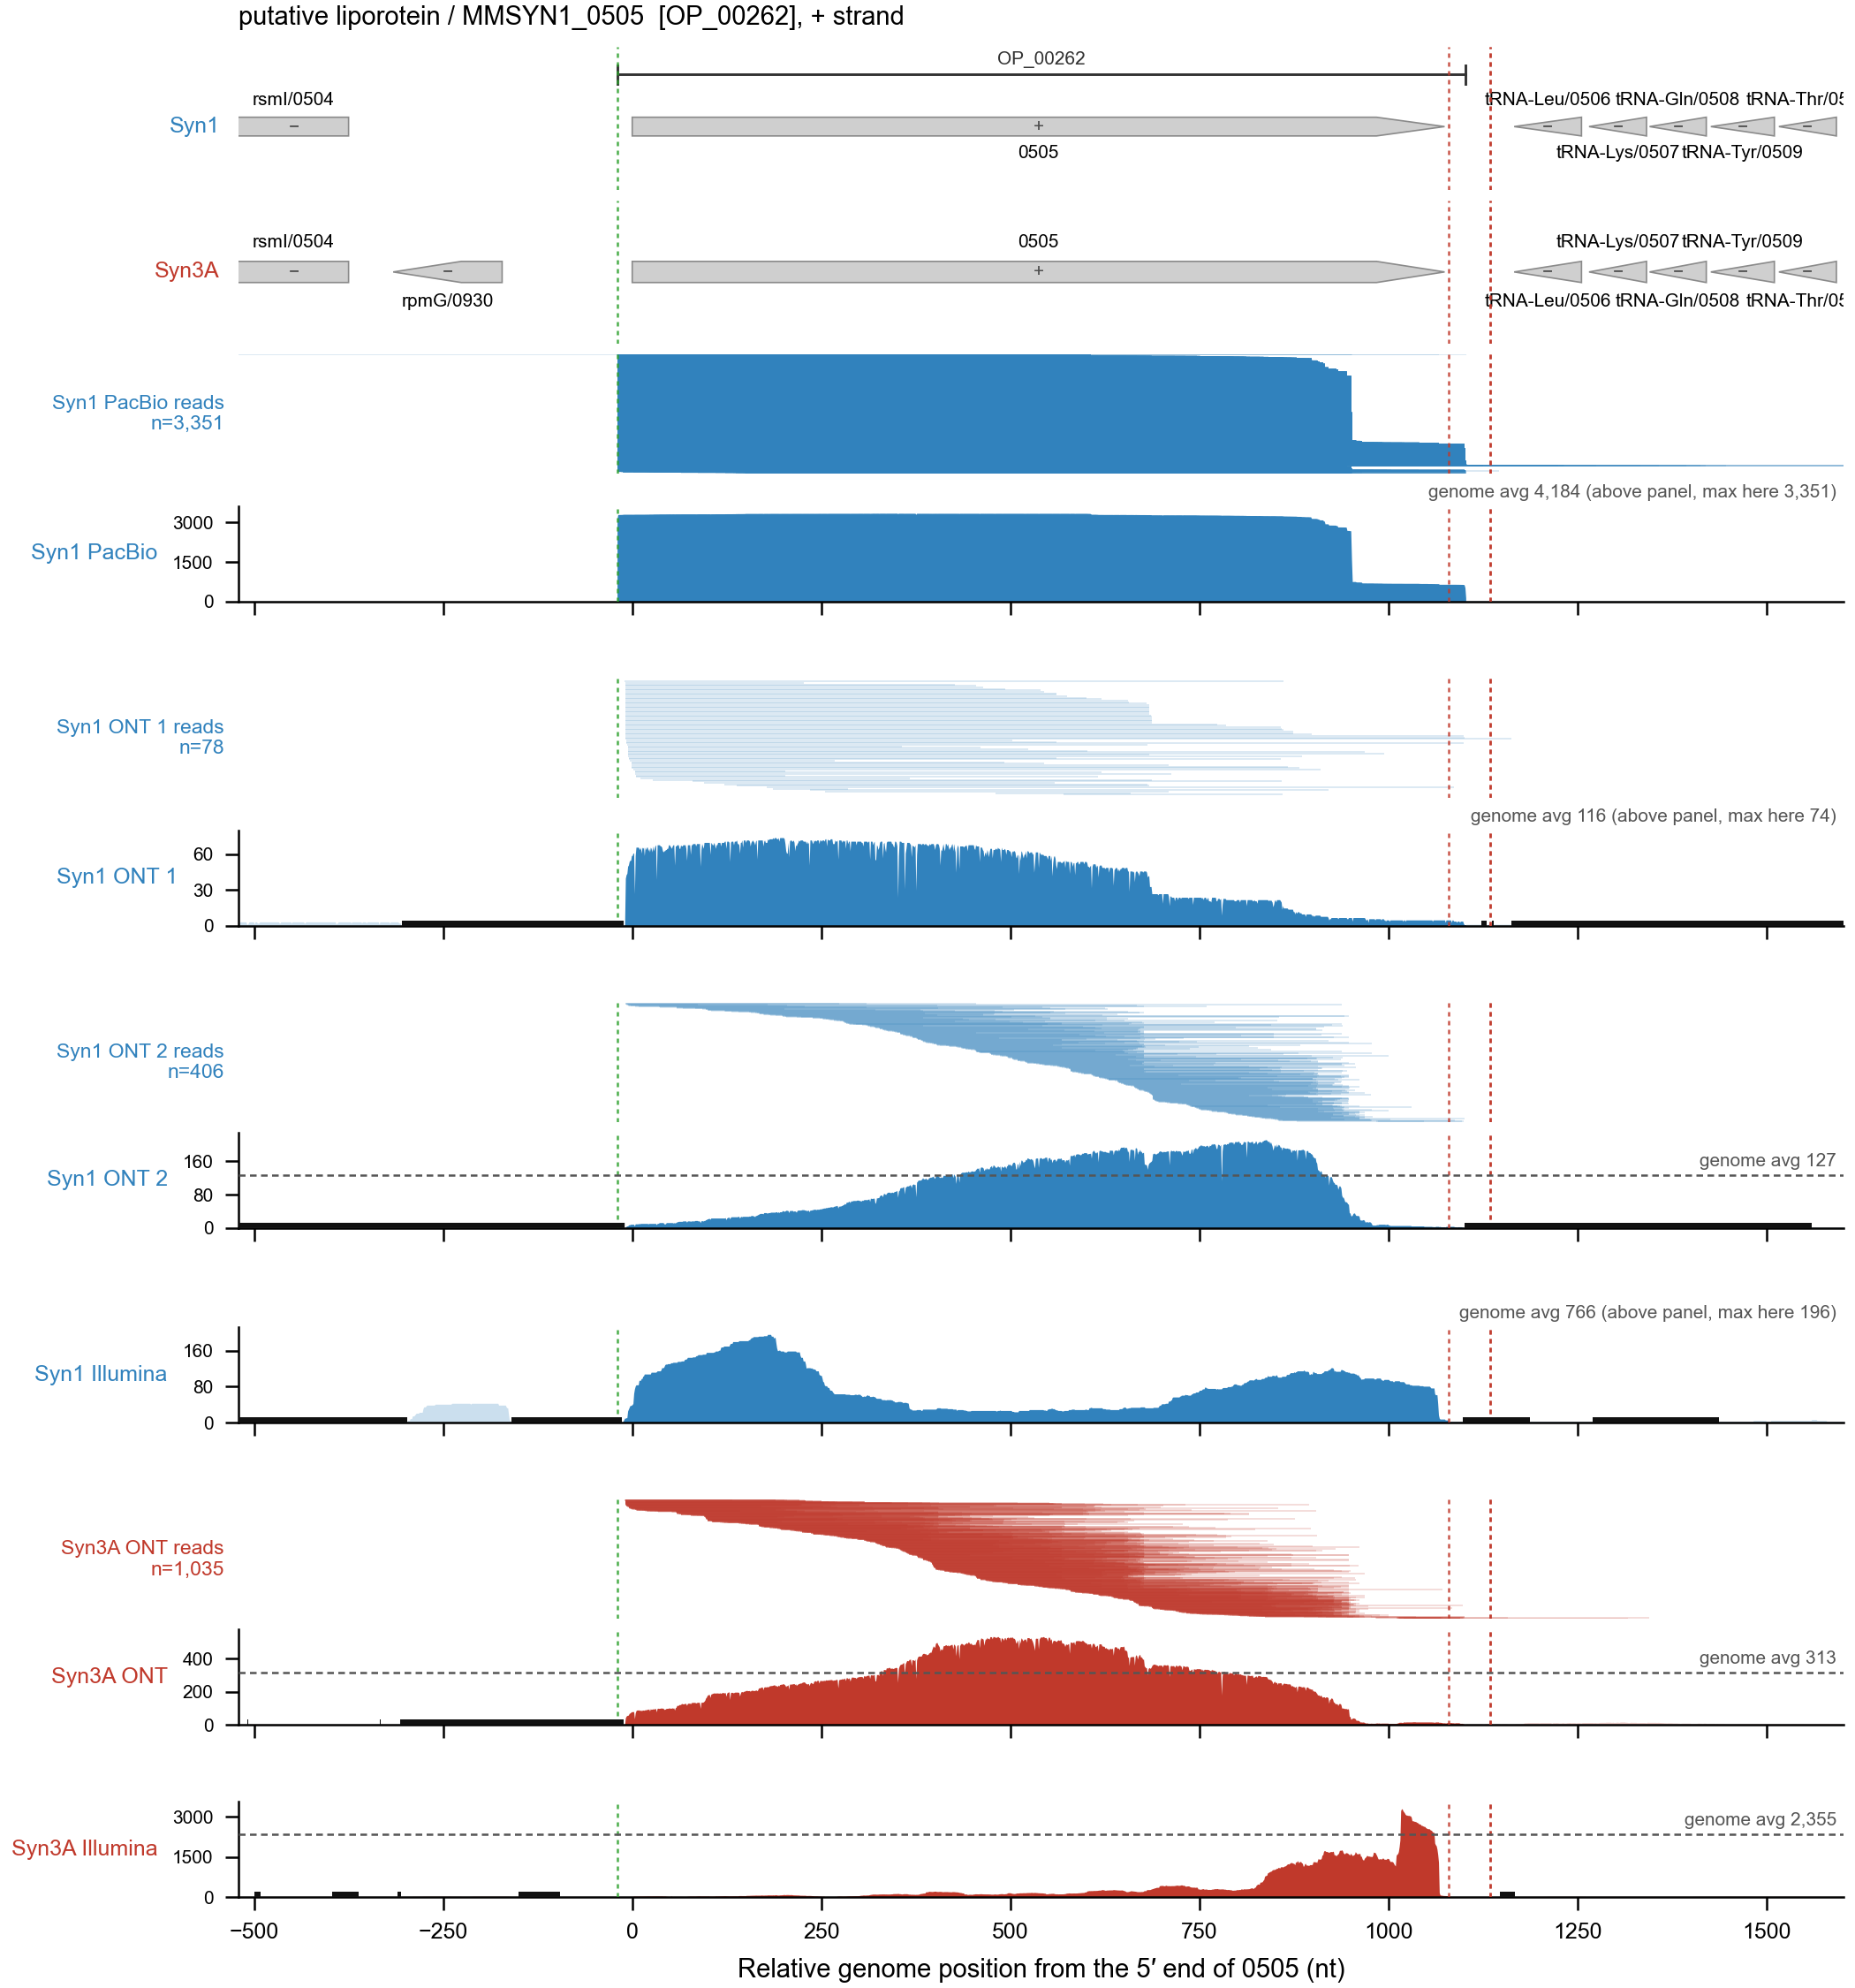

JCVISYN3A_0338  hyp  |  378 copies/cell


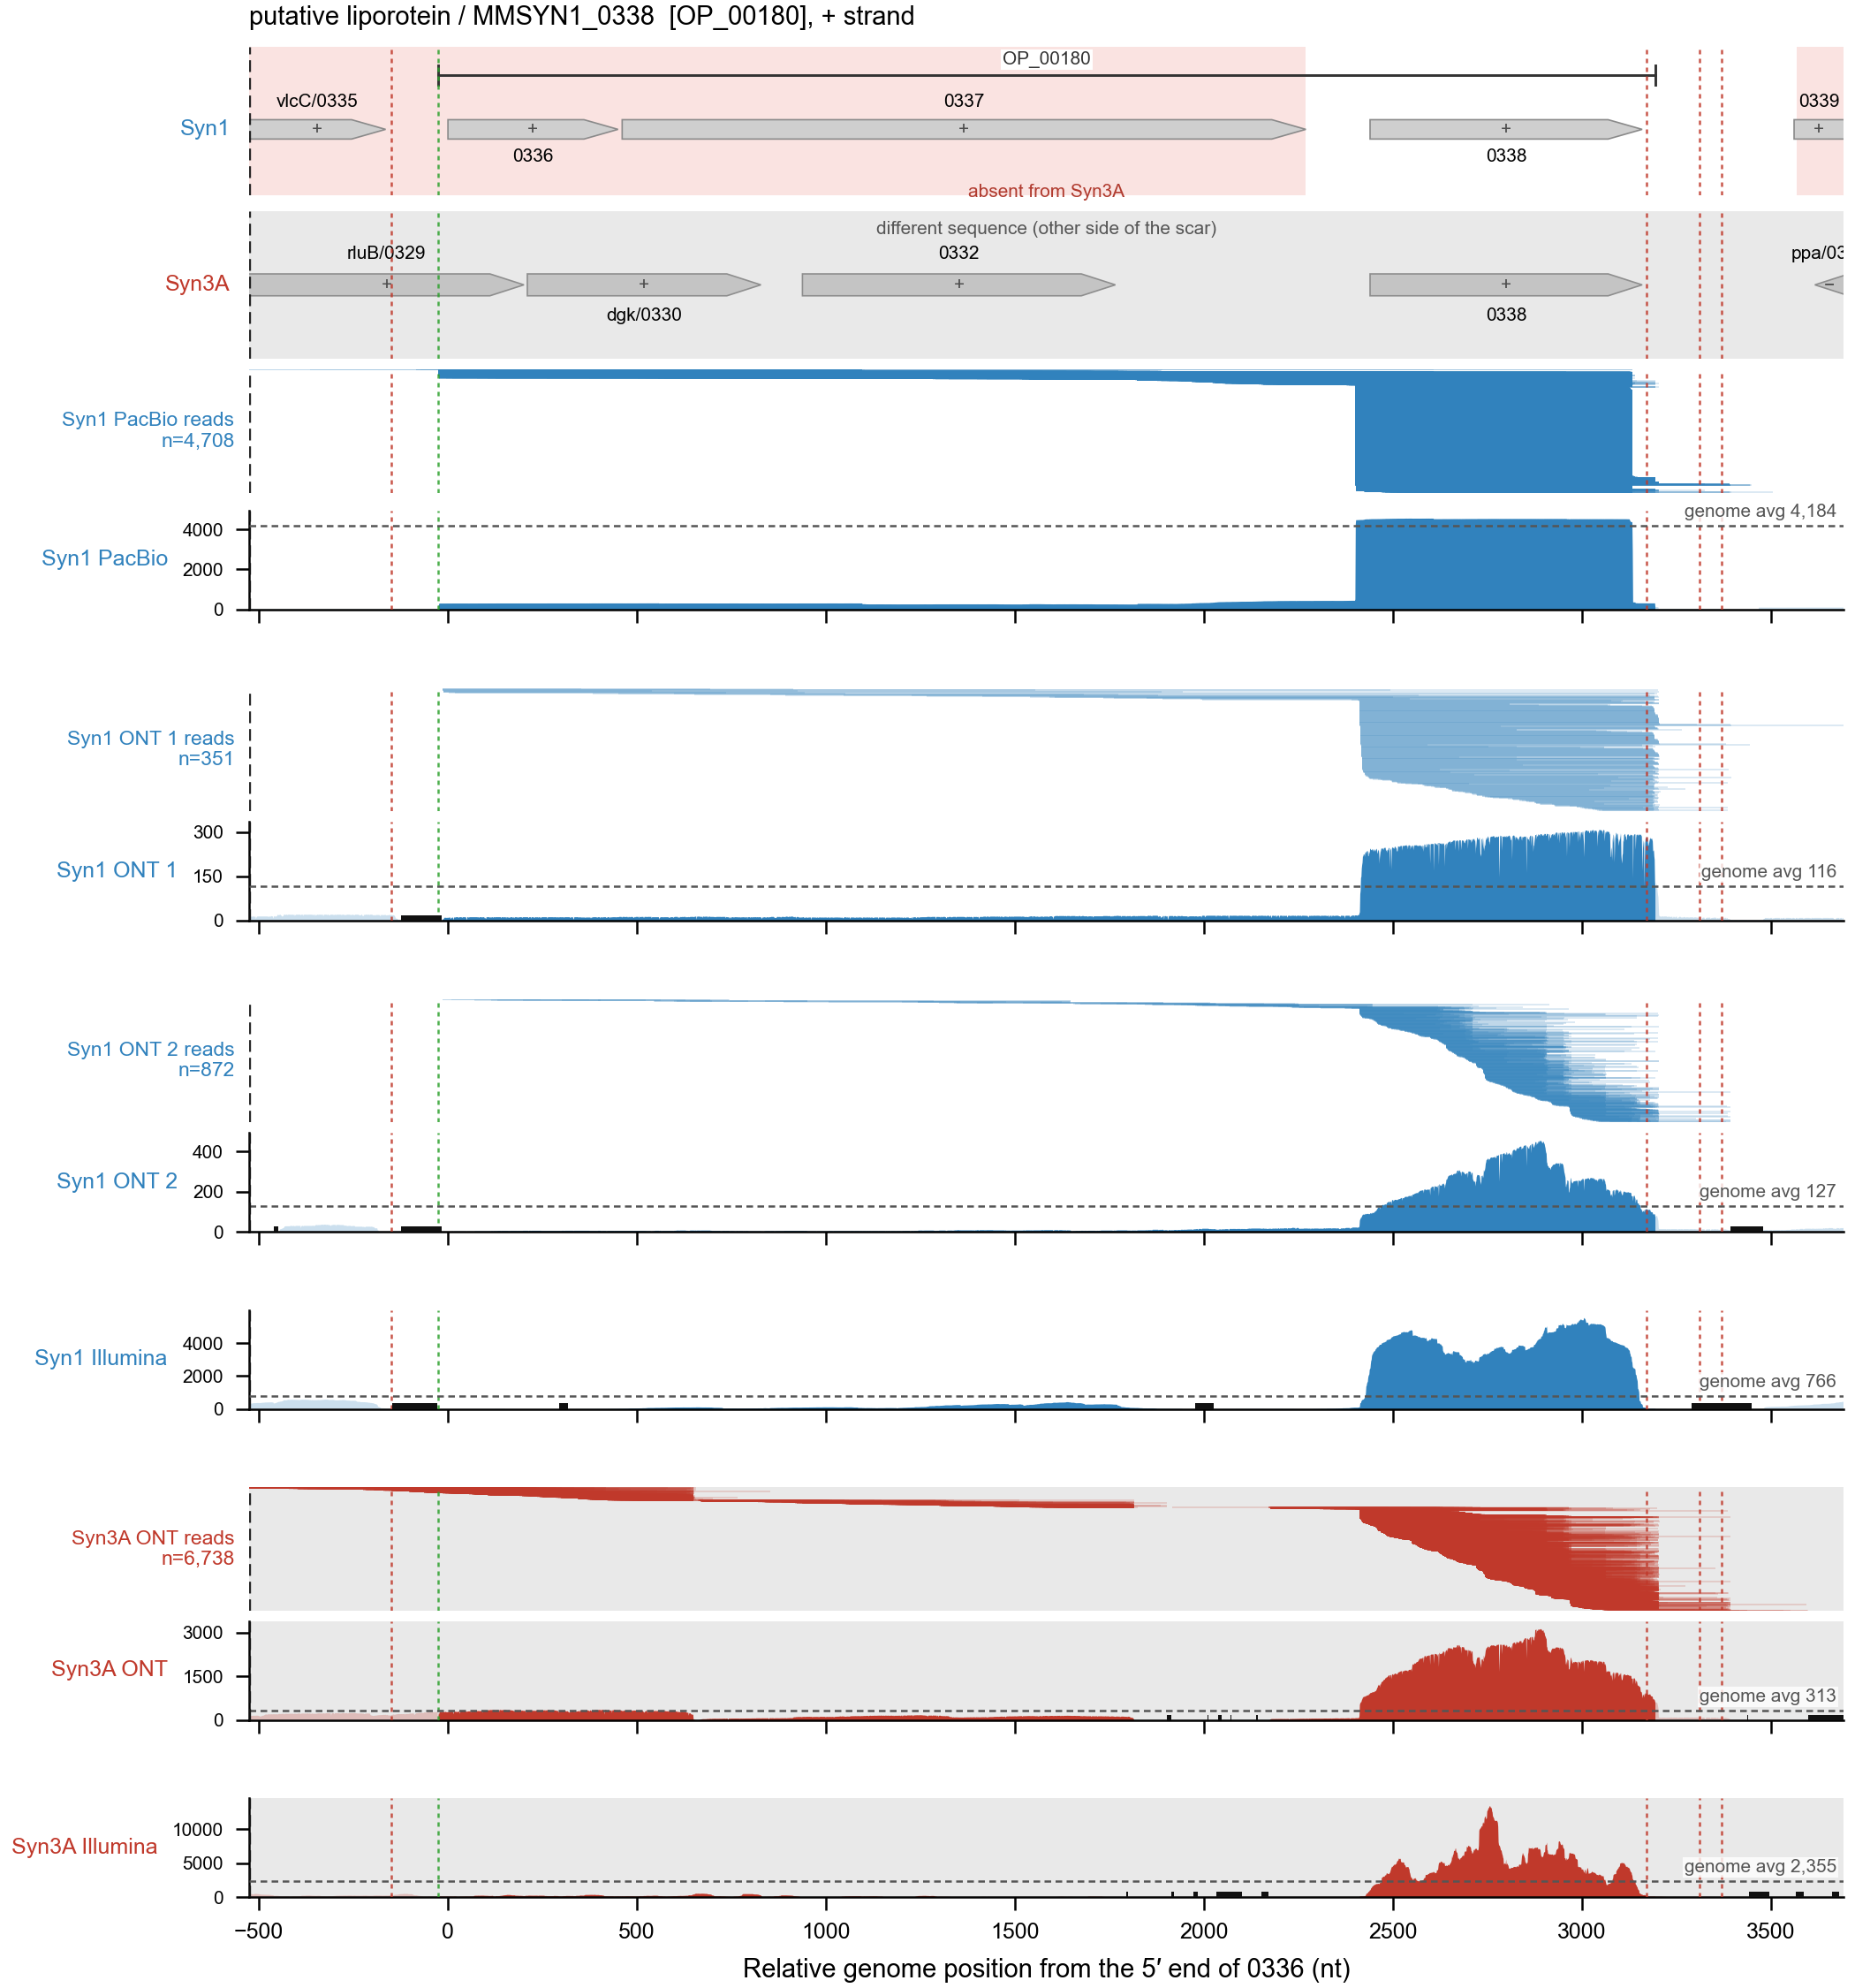

JCVISYN3A_0604  hyp  |  364 copies/cell


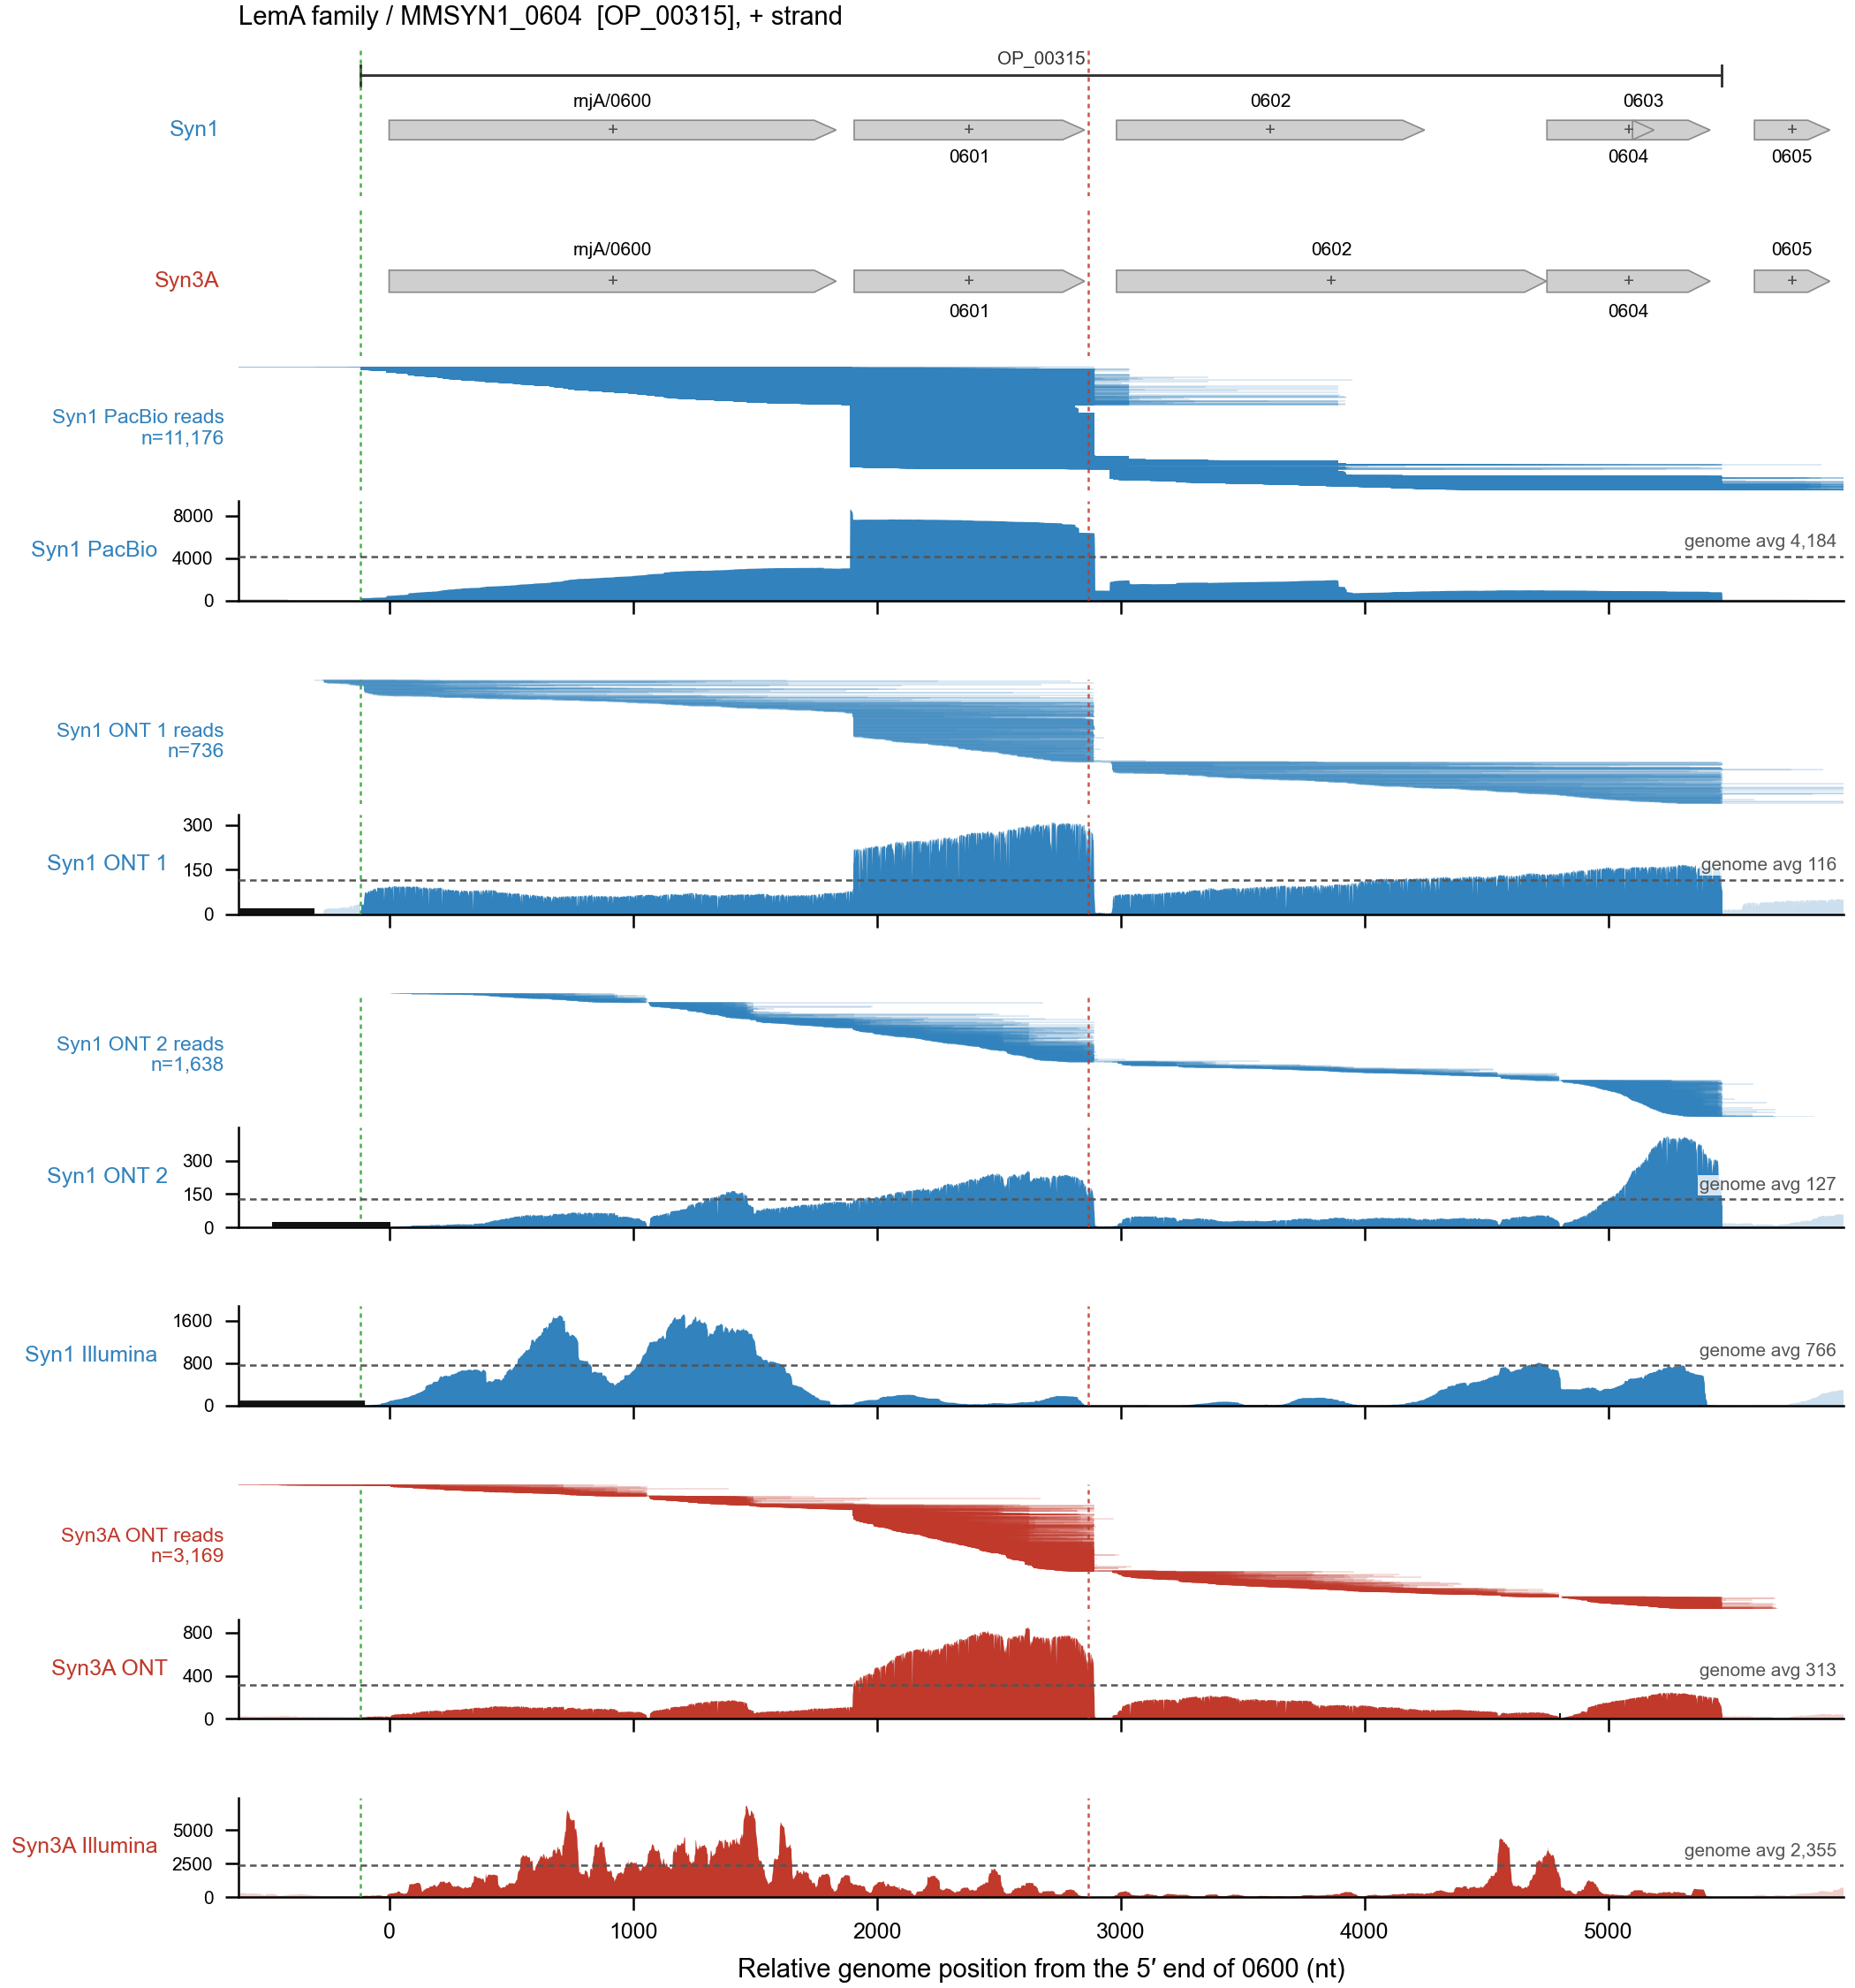

JCVISYN3A_0439  hyp  |  335 copies/cell


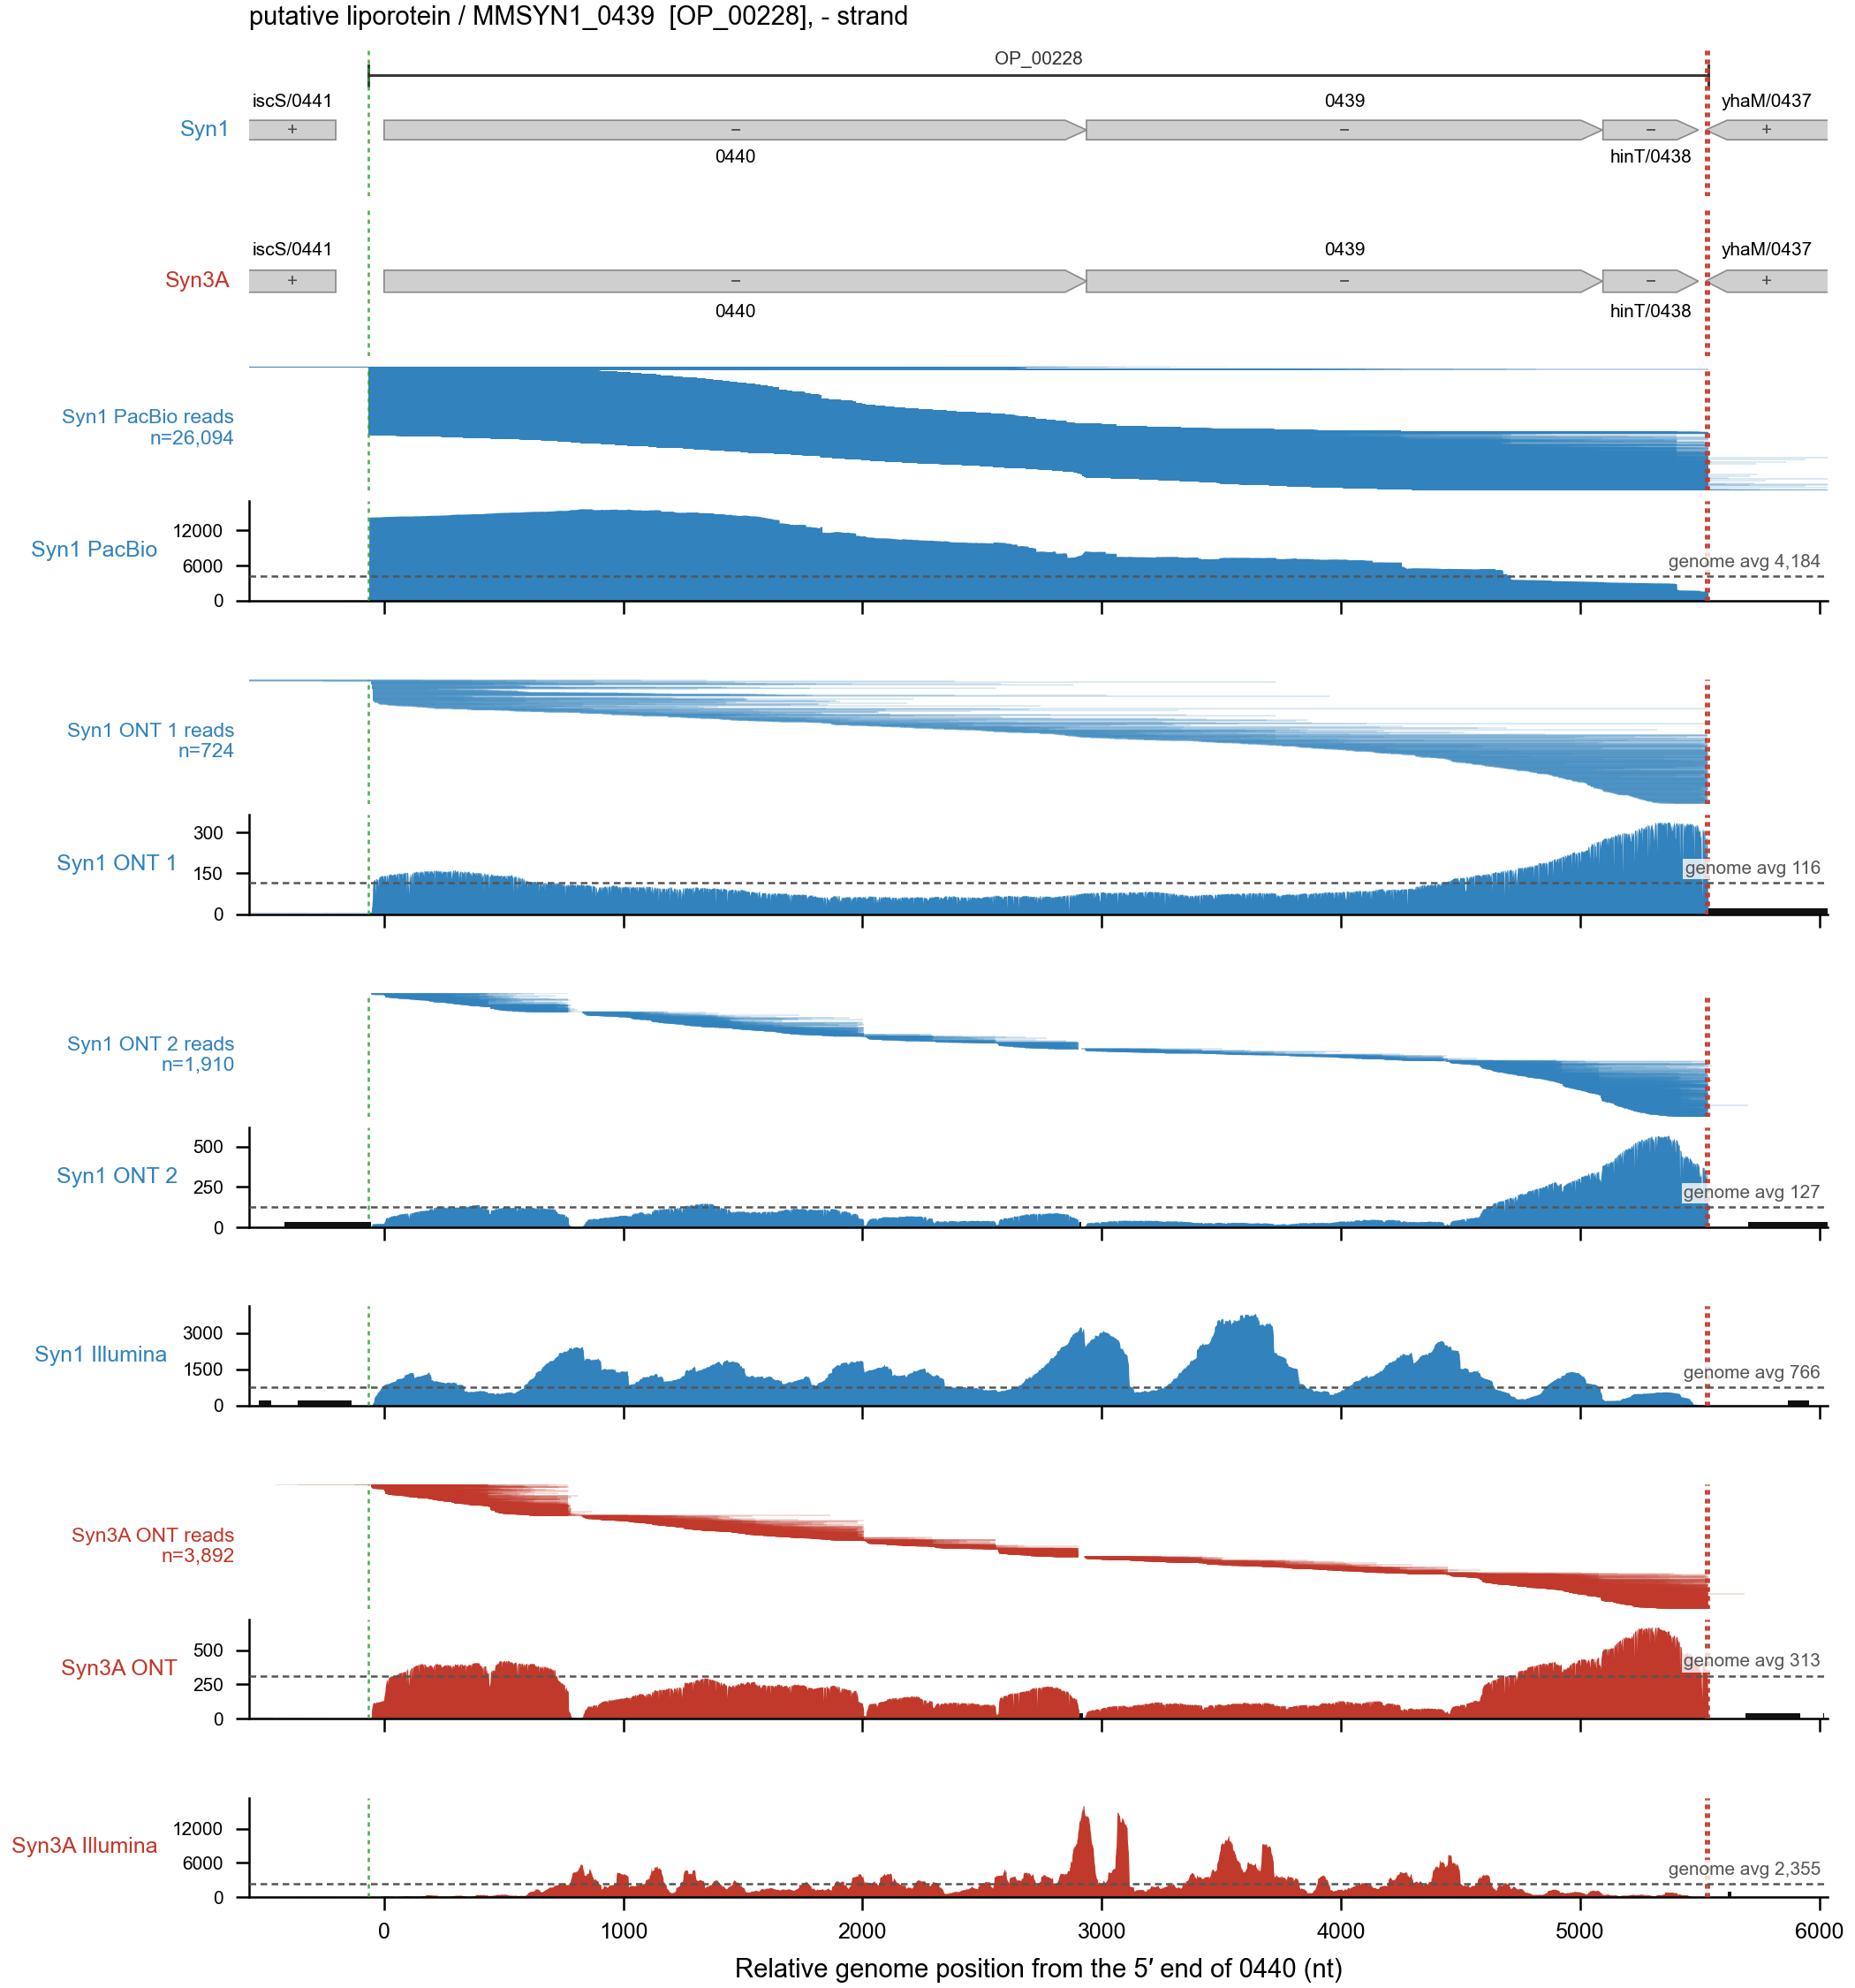

JCVISYN3A_0530  hyp  |  315 copies/cell


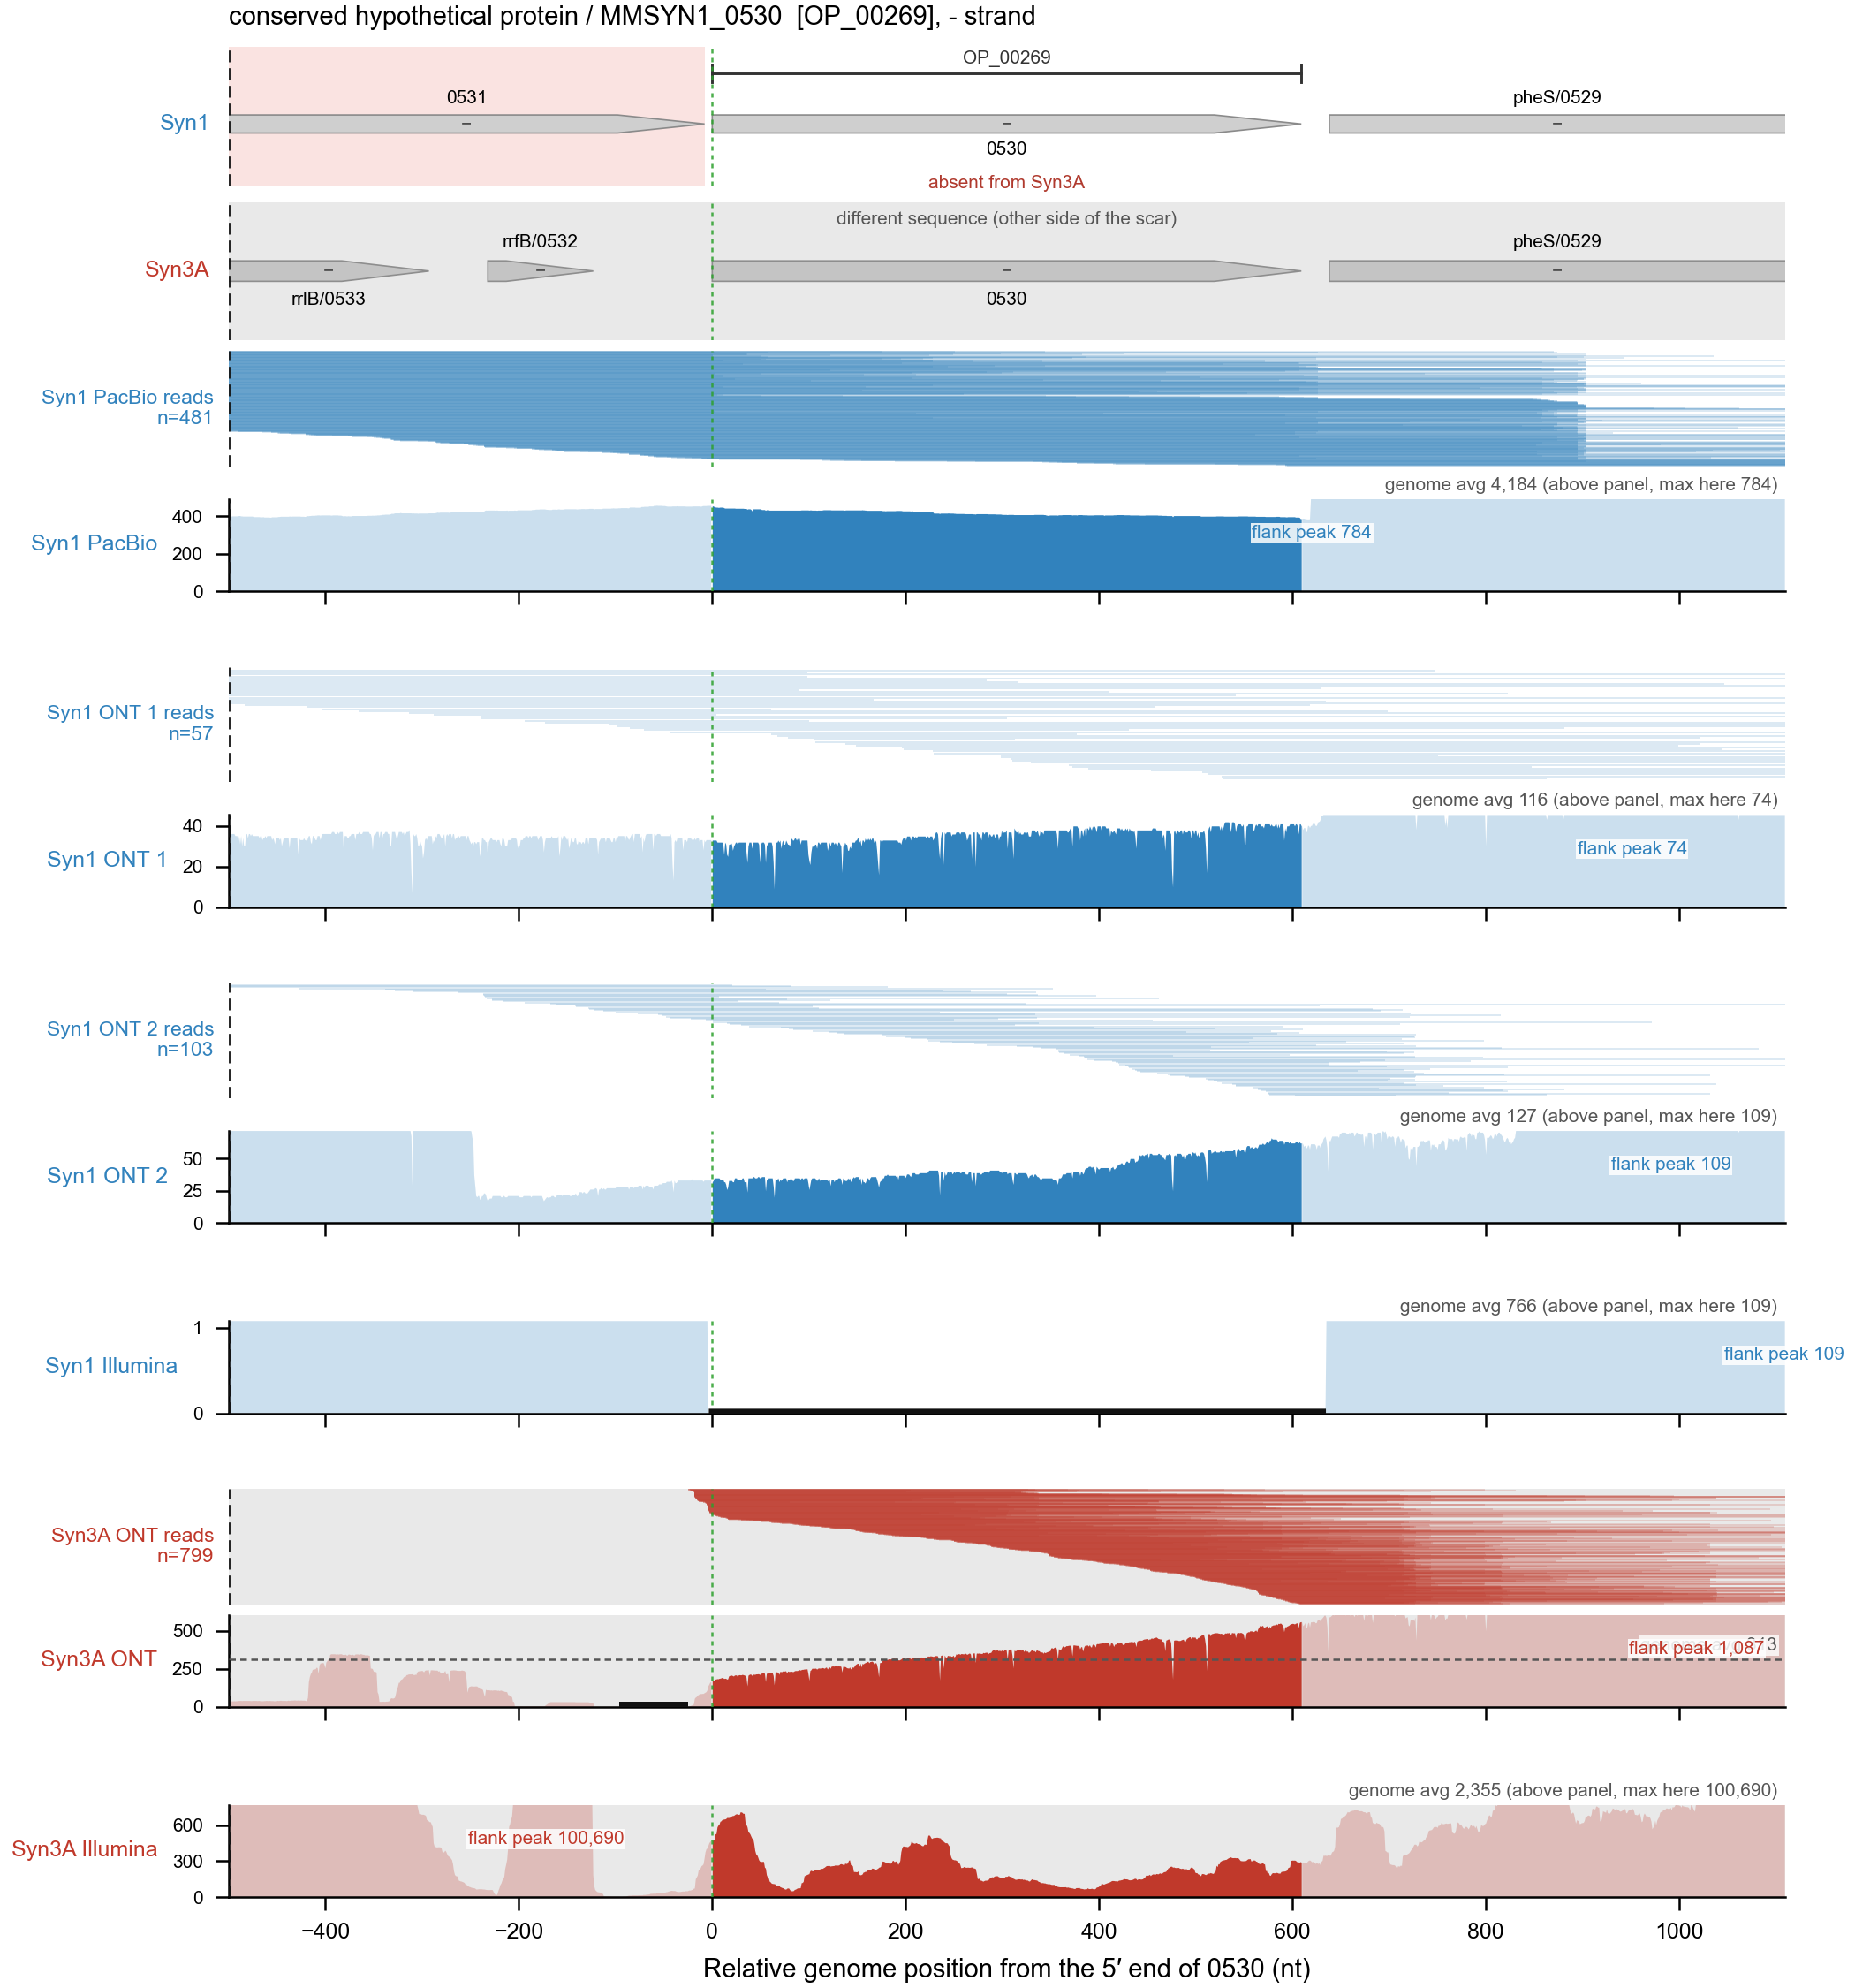

JCVISYN3A_0440  hyp  |  297 copies/cell


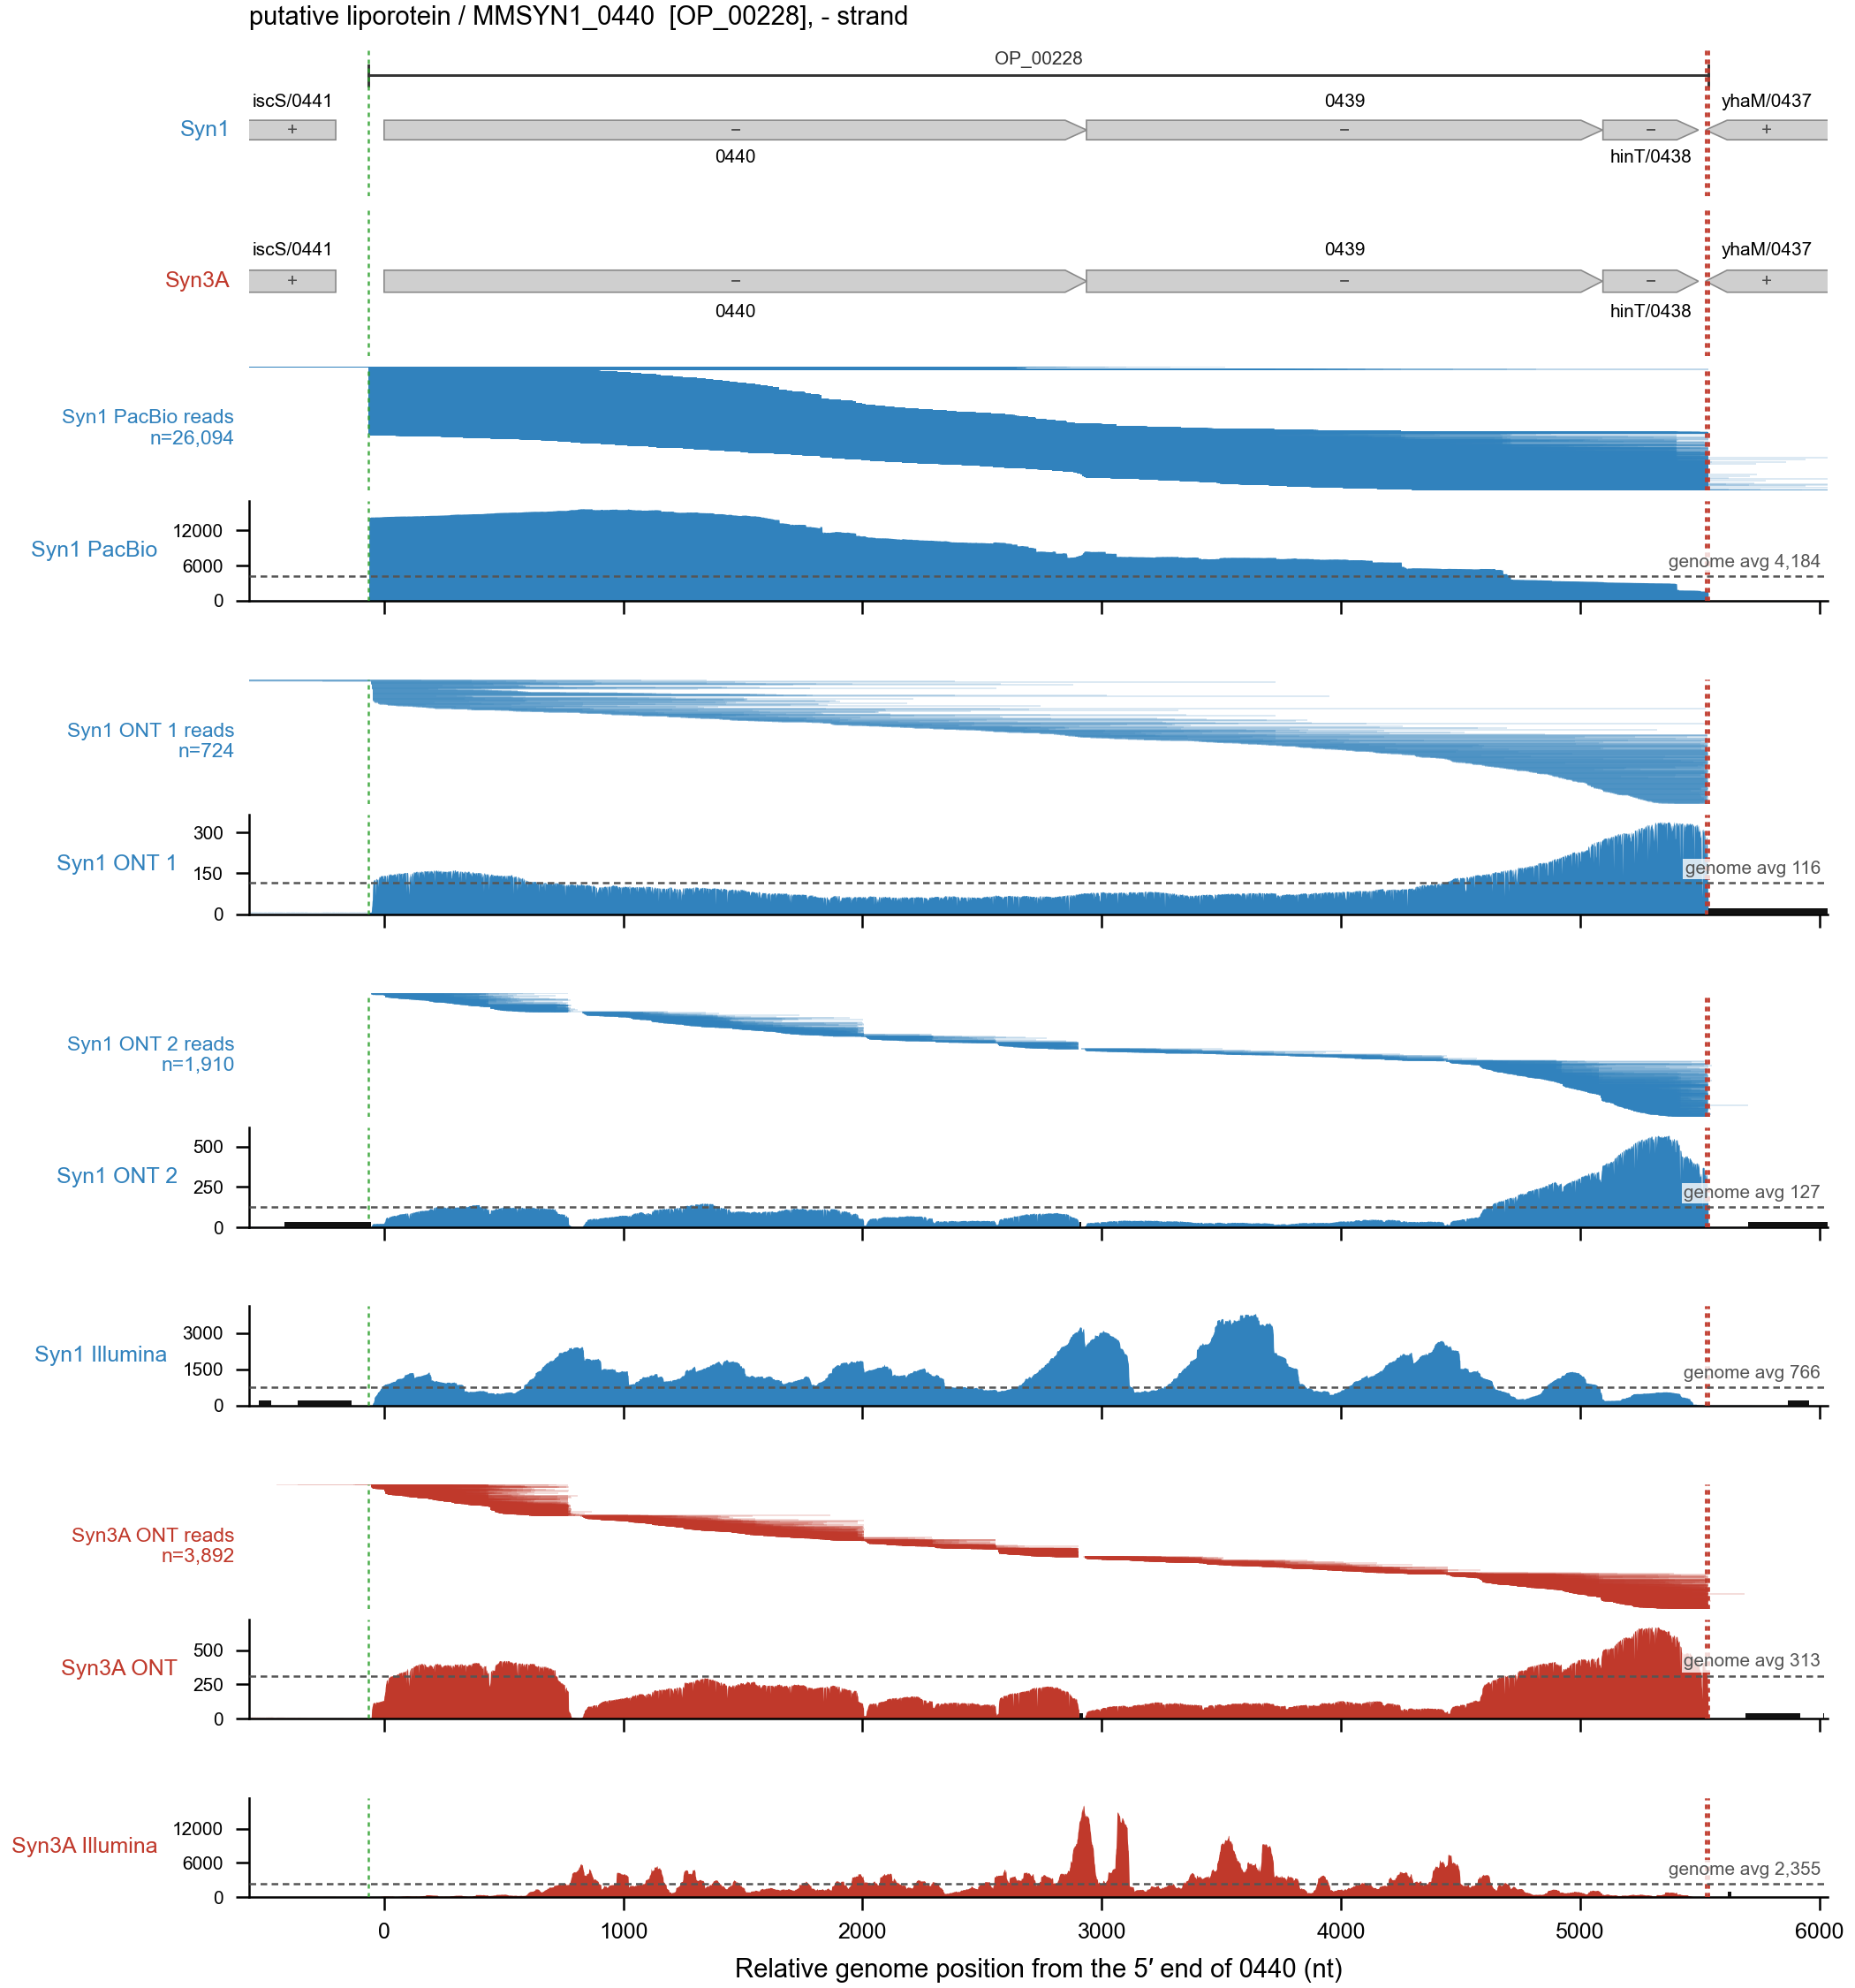

In [2]:
import os, pandas as pd

UNCLEAR_DIR = os.path.join(tv.OUTDIR, "unclear")
SHOW_N = 6          # rendered inline; ALL of them are written to UNCLEAR_DIR either way

prot = tv.load_syn3a_proteome()
unclear = prot[prot["Primary Function"] == "Unclear"]
print(f"{len(unclear)} Syn3A proteins with Primary Function == 'Unclear'")

drawn, skipped = [], []
for num, r in unclear.iterrows():
    try:
        fig, txt, R = tv.plot_region(num, outdir=UNCLEAR_DIR)
        tv.plt.close(fig)                      # 74 open figures would exhaust the backend
        drawn.append((num, R["label"], ", ".join(R["operons"]) or "-",
                      r["Exp. Ptn Cnt 2026"], r["mRNA Copies/Cell"], R["files"]["png"]))
    except Exception as e:
        skipped.append((num, f"{type(e).__name__}: {e}"))

done = pd.DataFrame(drawn, columns=["locus", "name", "operons", "ptn_2026",
                                    "mRNA_per_cell", "png"])
done = done.sort_values("ptn_2026", ascending=False, na_position="last")
print(f"drawn {len(done)}, skipped {len(skipped)} -> {UNCLEAR_DIR}")
for k, why in skipped:
    print(f"  {k}: {why}")
display(done.drop(columns="png").head(20))

for _, r in done.head(SHOW_N).iterrows():
    print(f"JCVISYN3A_{r.locus}  {r['name']}  |  {r.ptn_2026:,.0f} copies/cell")
    display(Image(filename=r.png, width=680))

## One gene

`GENE` takes any of `"ptsG"`, `"0779"`, `"MMSYN1_0779"`, `"JCVISYN3A_0779"`.

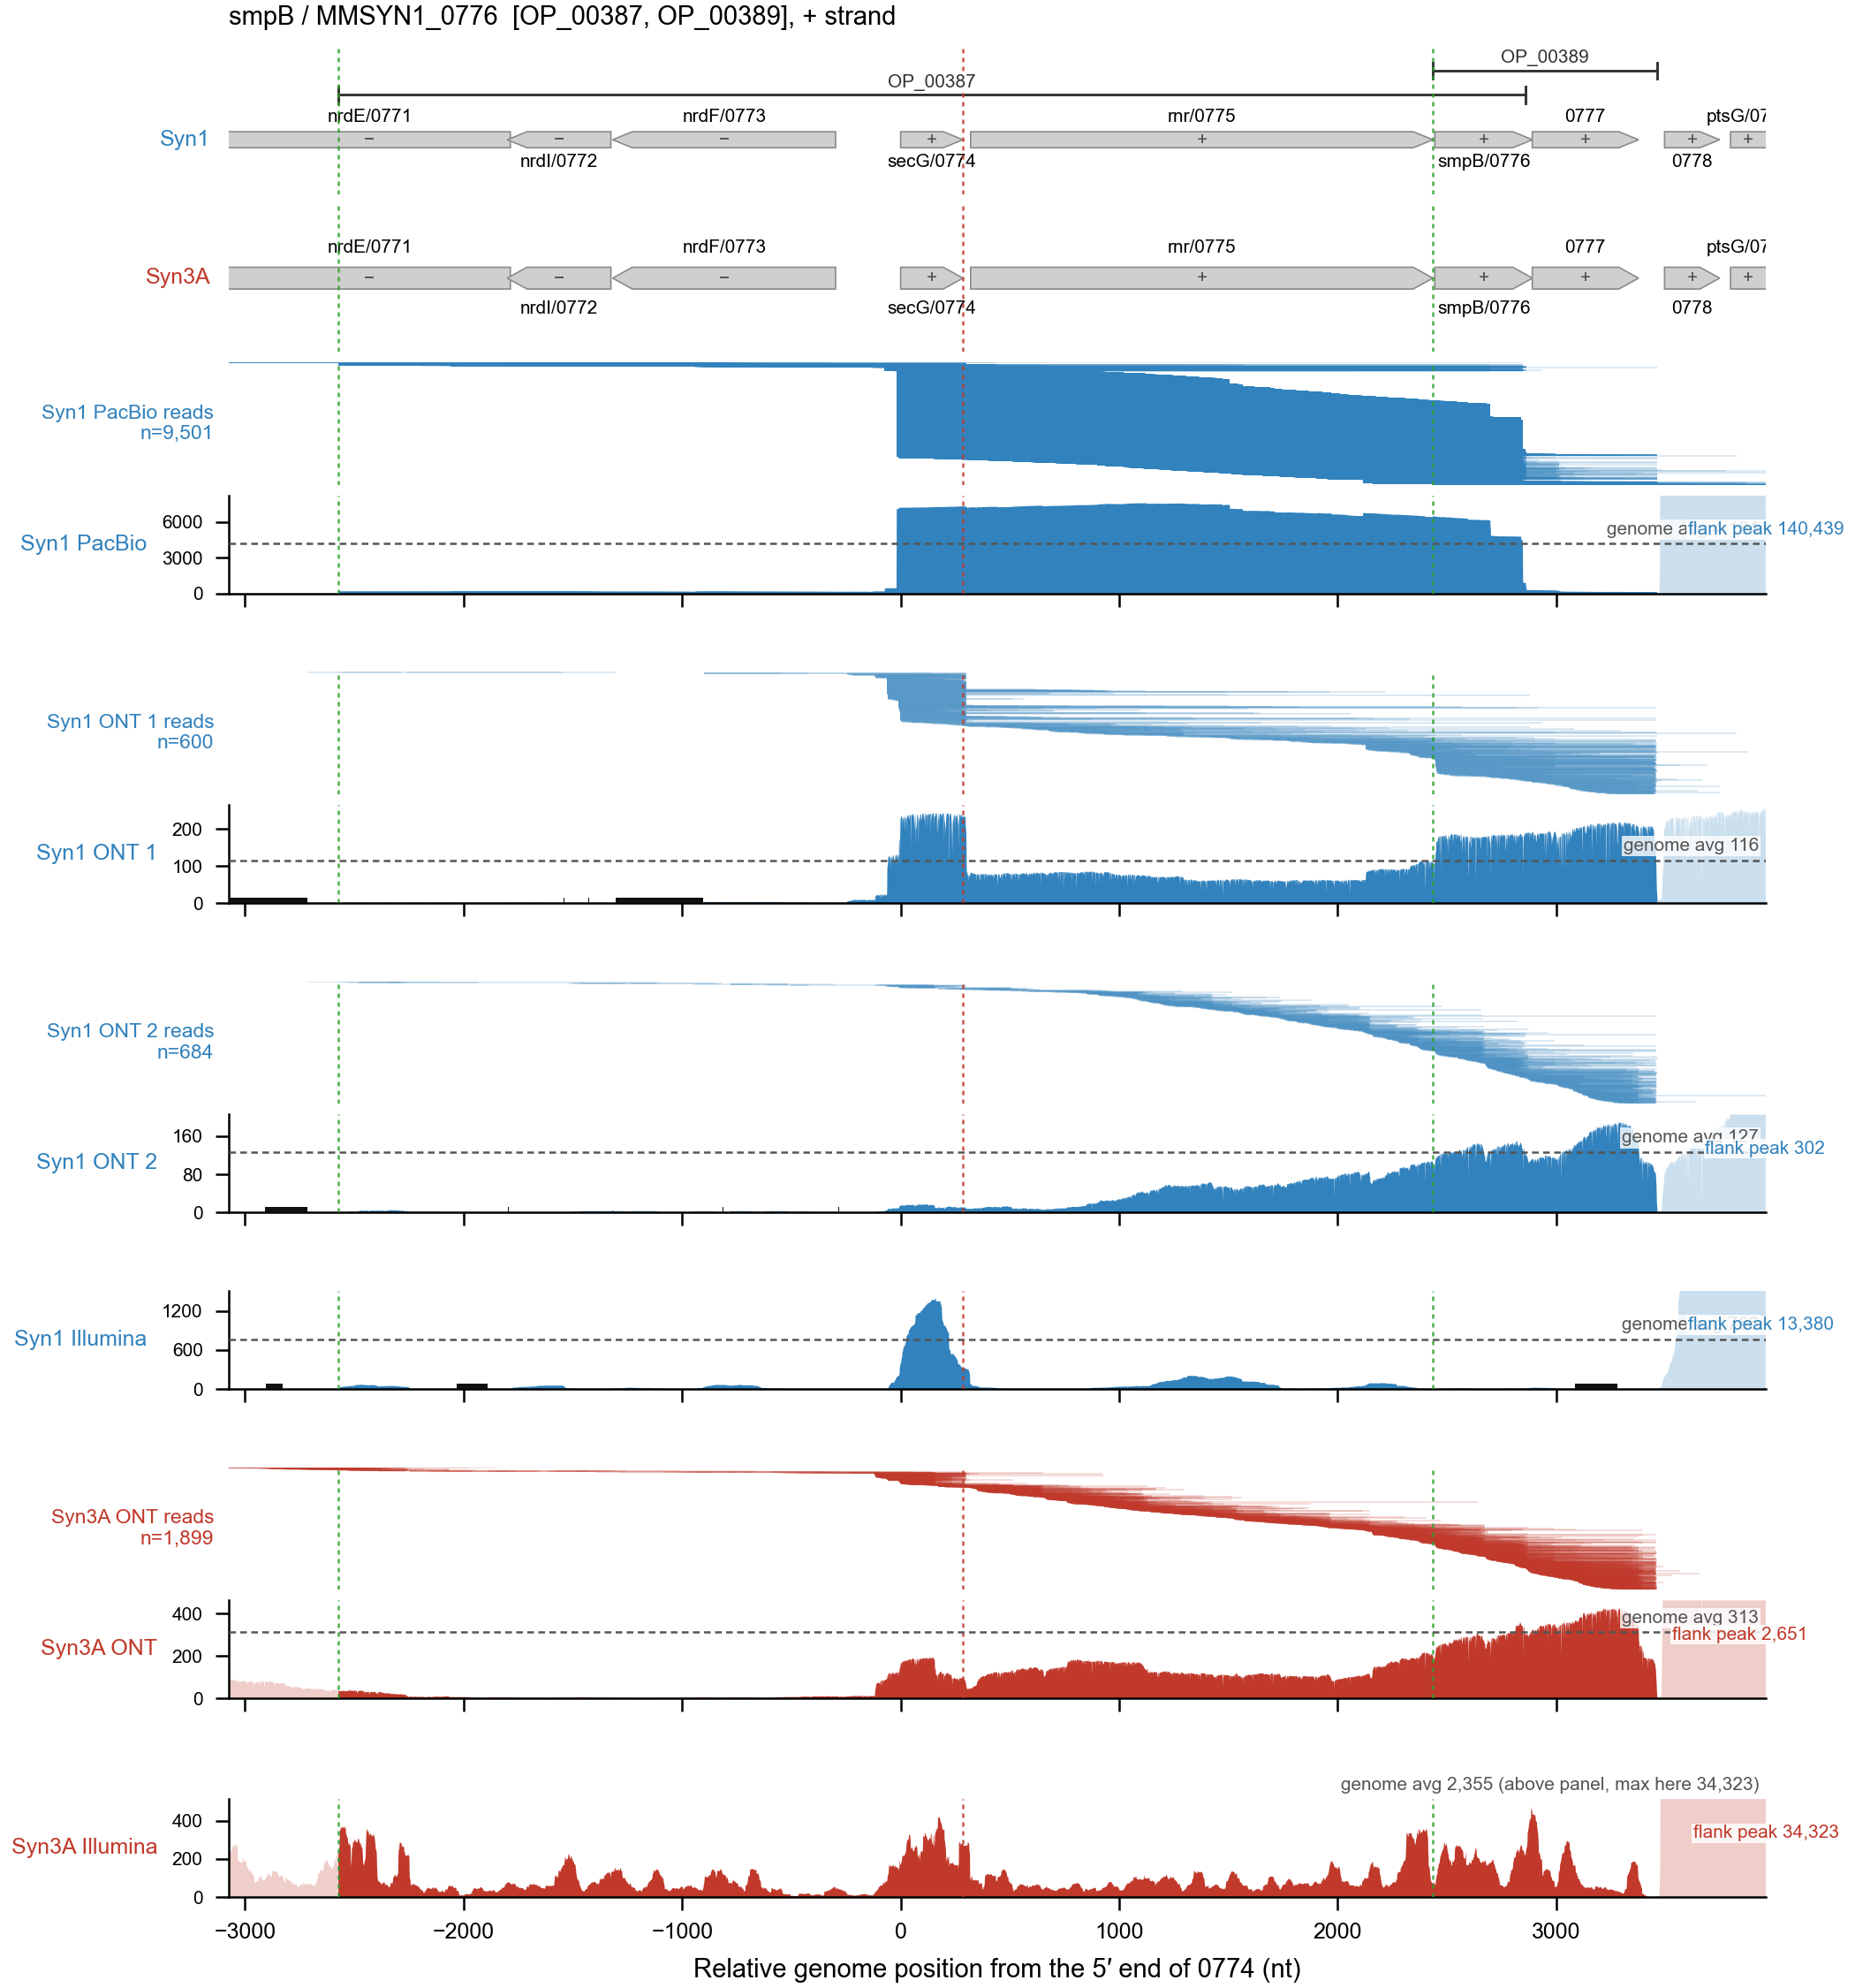

smpB / MMSYN1_0776  [OP_00387, OP_00389], + strand
anchor: Syn1 911,538, Syn3A 456,669
rel = pos - anchor;  window rel -3075 .. 3960  (Syn1 908,463-915,498)
operon block(s): OP_00387, OP_00389;  TSS 908,963, 913,972

Both-strand genome-mean depth per library (reference line):
  Syn1 PacBio     mean =   4184.1
  Syn1 ONT 1      mean =    115.8
  Syn1 ONT 2      mean =    127.1
  Syn1 Illumina   mean =    766.4
  Syn3A ONT       mean =    312.9
  Syn3A Illumina  mean =   2355.4

Per-gene mean SENSE depth (RAW per-base depth):

gene                syn1PacBio      syn1ONT1      syn1ONT2  syn1Illumina      syn3aONT syn3aIllumina
secG/0774              7260.15        230.42         14.42        952.99        149.63        269.86
rnr/0775               7132.97         73.69         48.60         60.92        133.30         93.32
smpB/0776              5225.10        177.16        130.64         11.21        286.76        201.63
hyp/0777                215.32        197.14        150.14       

In [3]:
GENE = "smpB"

fig, txt, R = tv.plot_region(GENE)   # defaults: scale="abs", rows="all", mode="stack"

tv.show(R)          # scaled to fit one screen; the exported PDF/PNG stay 7 in wide
print(txt)

## Options

| argument | default | alternatives |
|---|---|---|
| `scale` | `"abs"` raw per-base depth, own axis per library | `"log"` / `"linear"` — × that library's genome mean, shared axis |
| `rows` | `"all"` one row per transcript | any positive **integer** — even subsample to that many rows |
| `mode` | `"stack"` read stacks + depth | `"pacbio"` — one PacBio isoform-cluster panel instead |
| `flank` | `500` bp each side of the operon | any int |

Only transcripts that **overlap the operon** are eligible for a row — one lying entirely in the flank says nothing about this operon, so it is dropped before subsampling. `rows="all"` on a highly expressed gene means a lot of lines (ptsG draws 162k), so the panel reads as read *density* rather than countable molecules, and the PDF gets large. Pass an integer when you want rows you can count; ~190 is the most that stay individually resolvable at this panel height.

The figure is born at 7 in wide (Nature 2-column) and must stay that size, so shrink the *rendering*, not the figure: `tv.show(R, width=680)` displays the saved PNG at a given pixel width. `width=520` fits a tall panel on one screen.


## Several genes

Genome-mean depths are cached per library, so the first call pays for them and the rest are fast.

ptsG / MMSYN1_0779  [OP_00390], + strand   ->  0779_ptsG_transcription.png


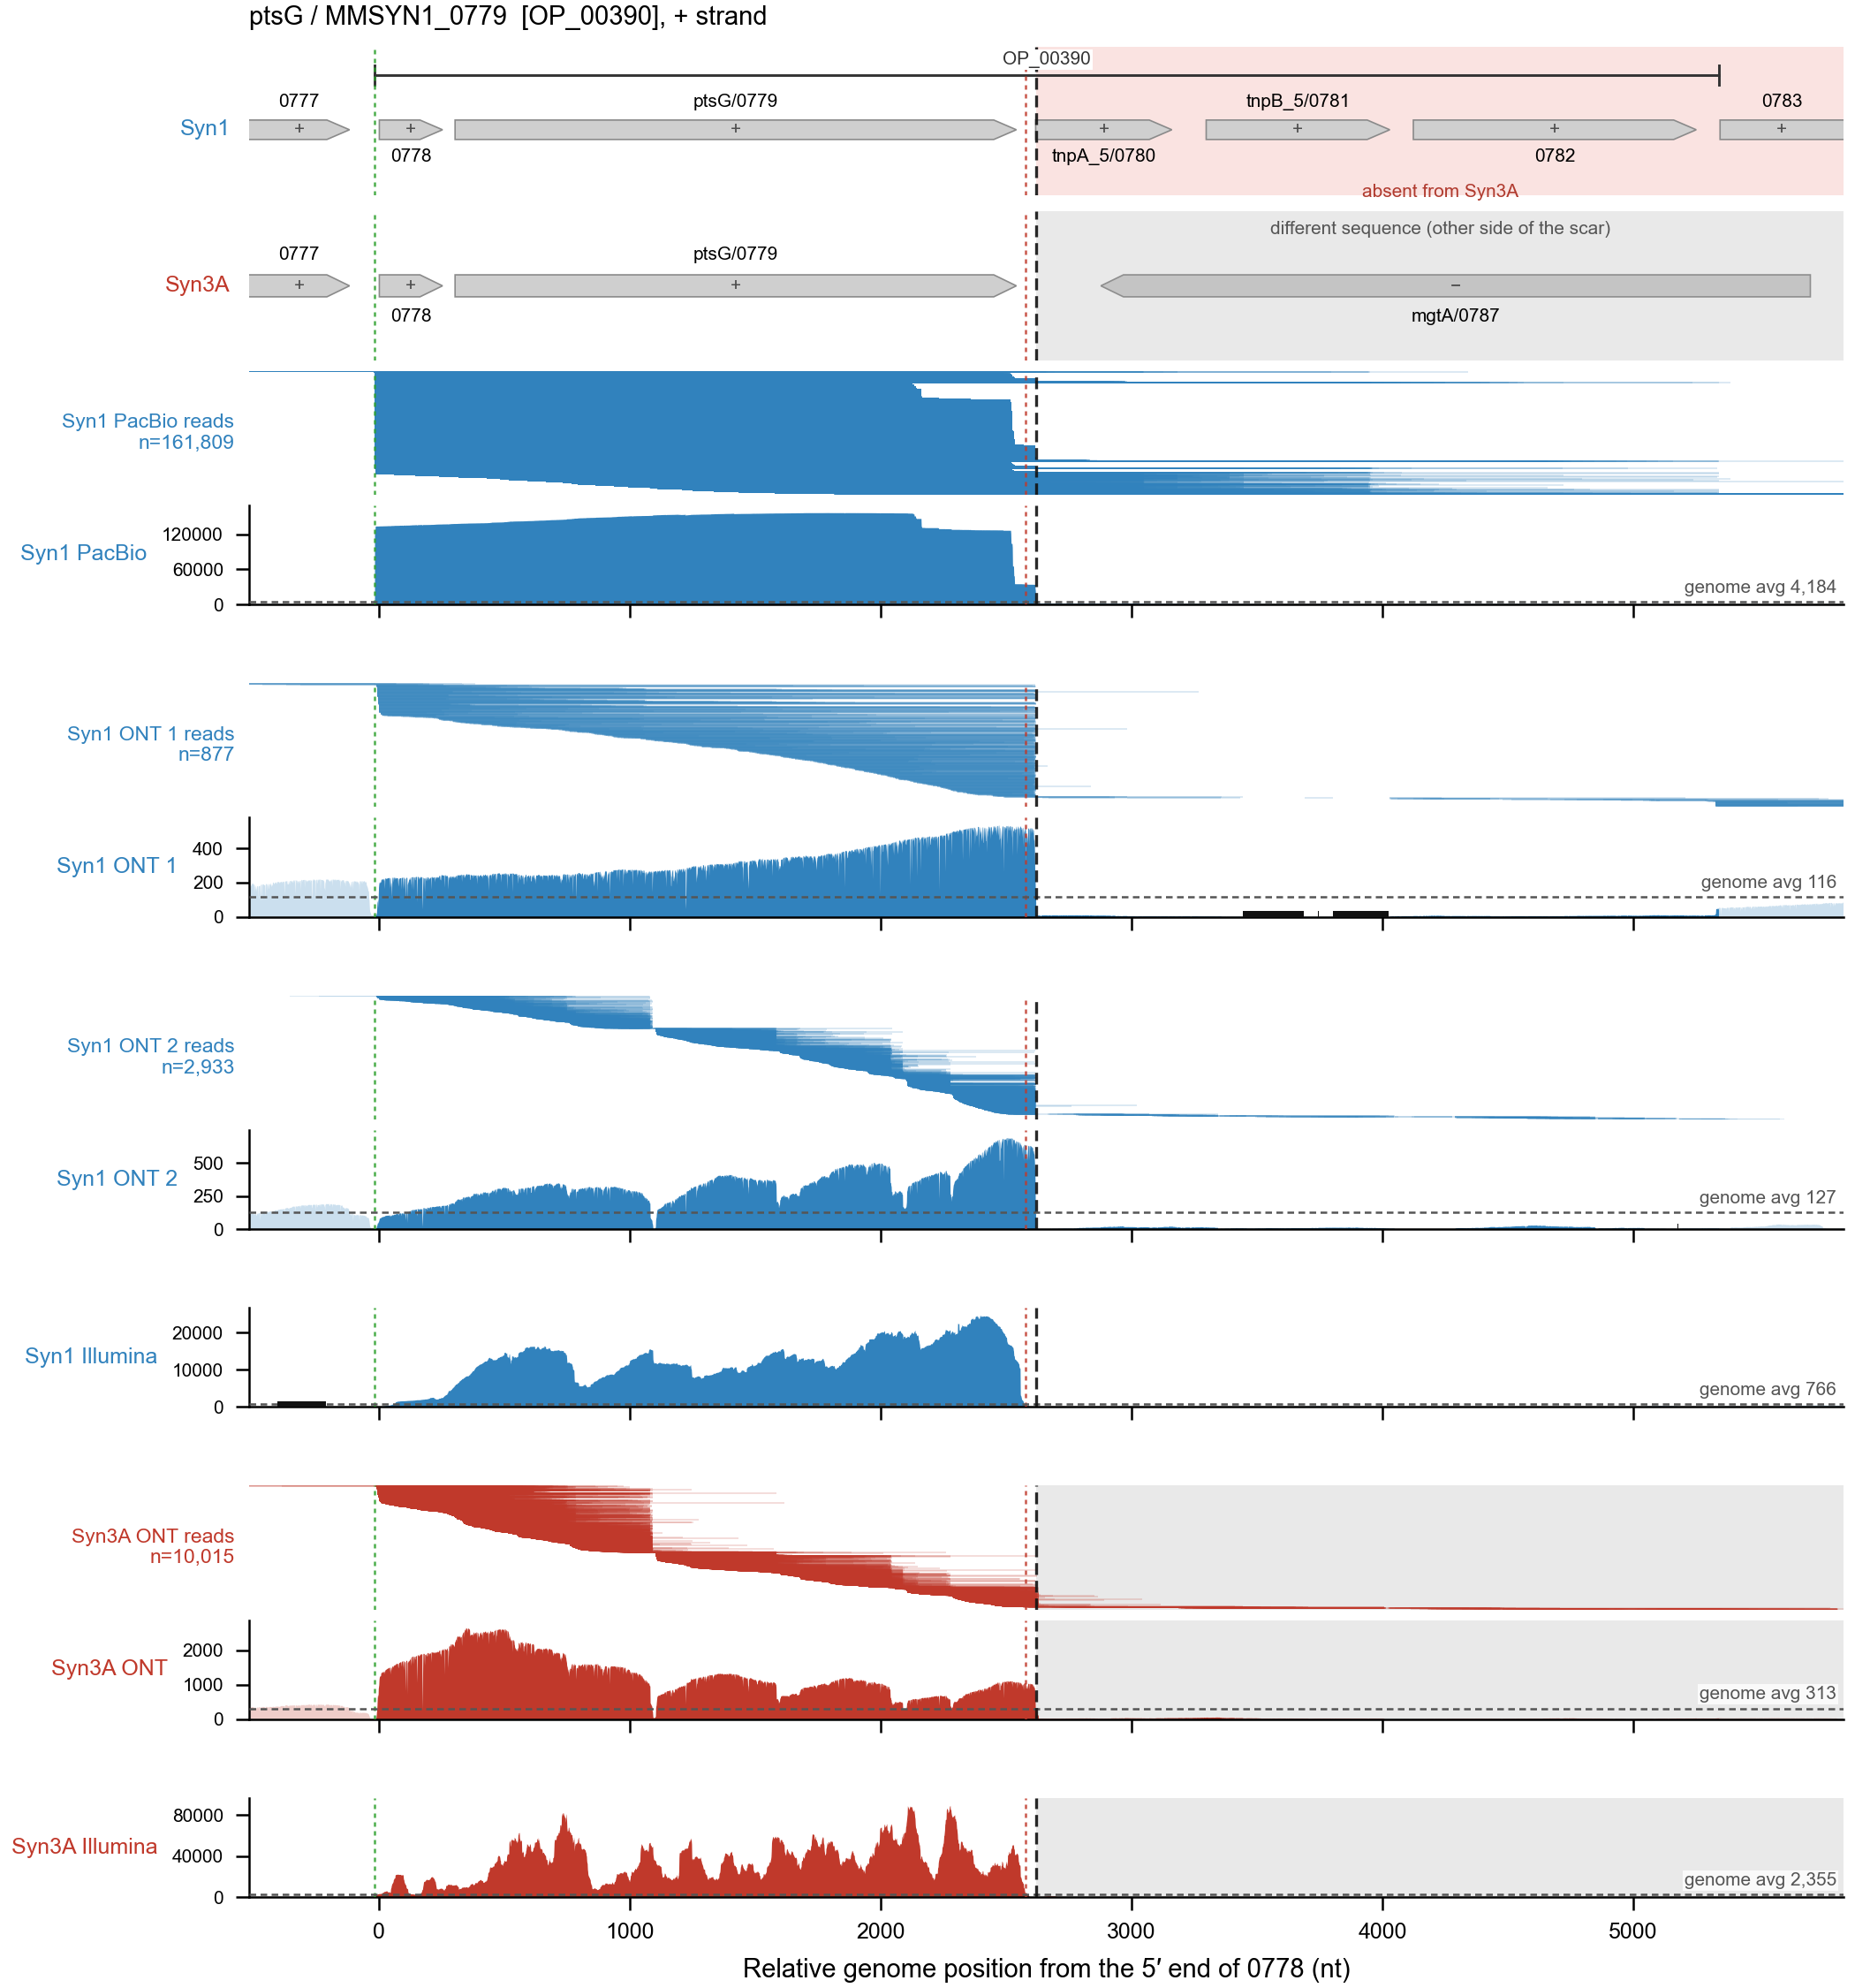

ftsZ / MMSYN1_0522  [OP_00266], - strand   ->  0522_ftsZ_transcription.png


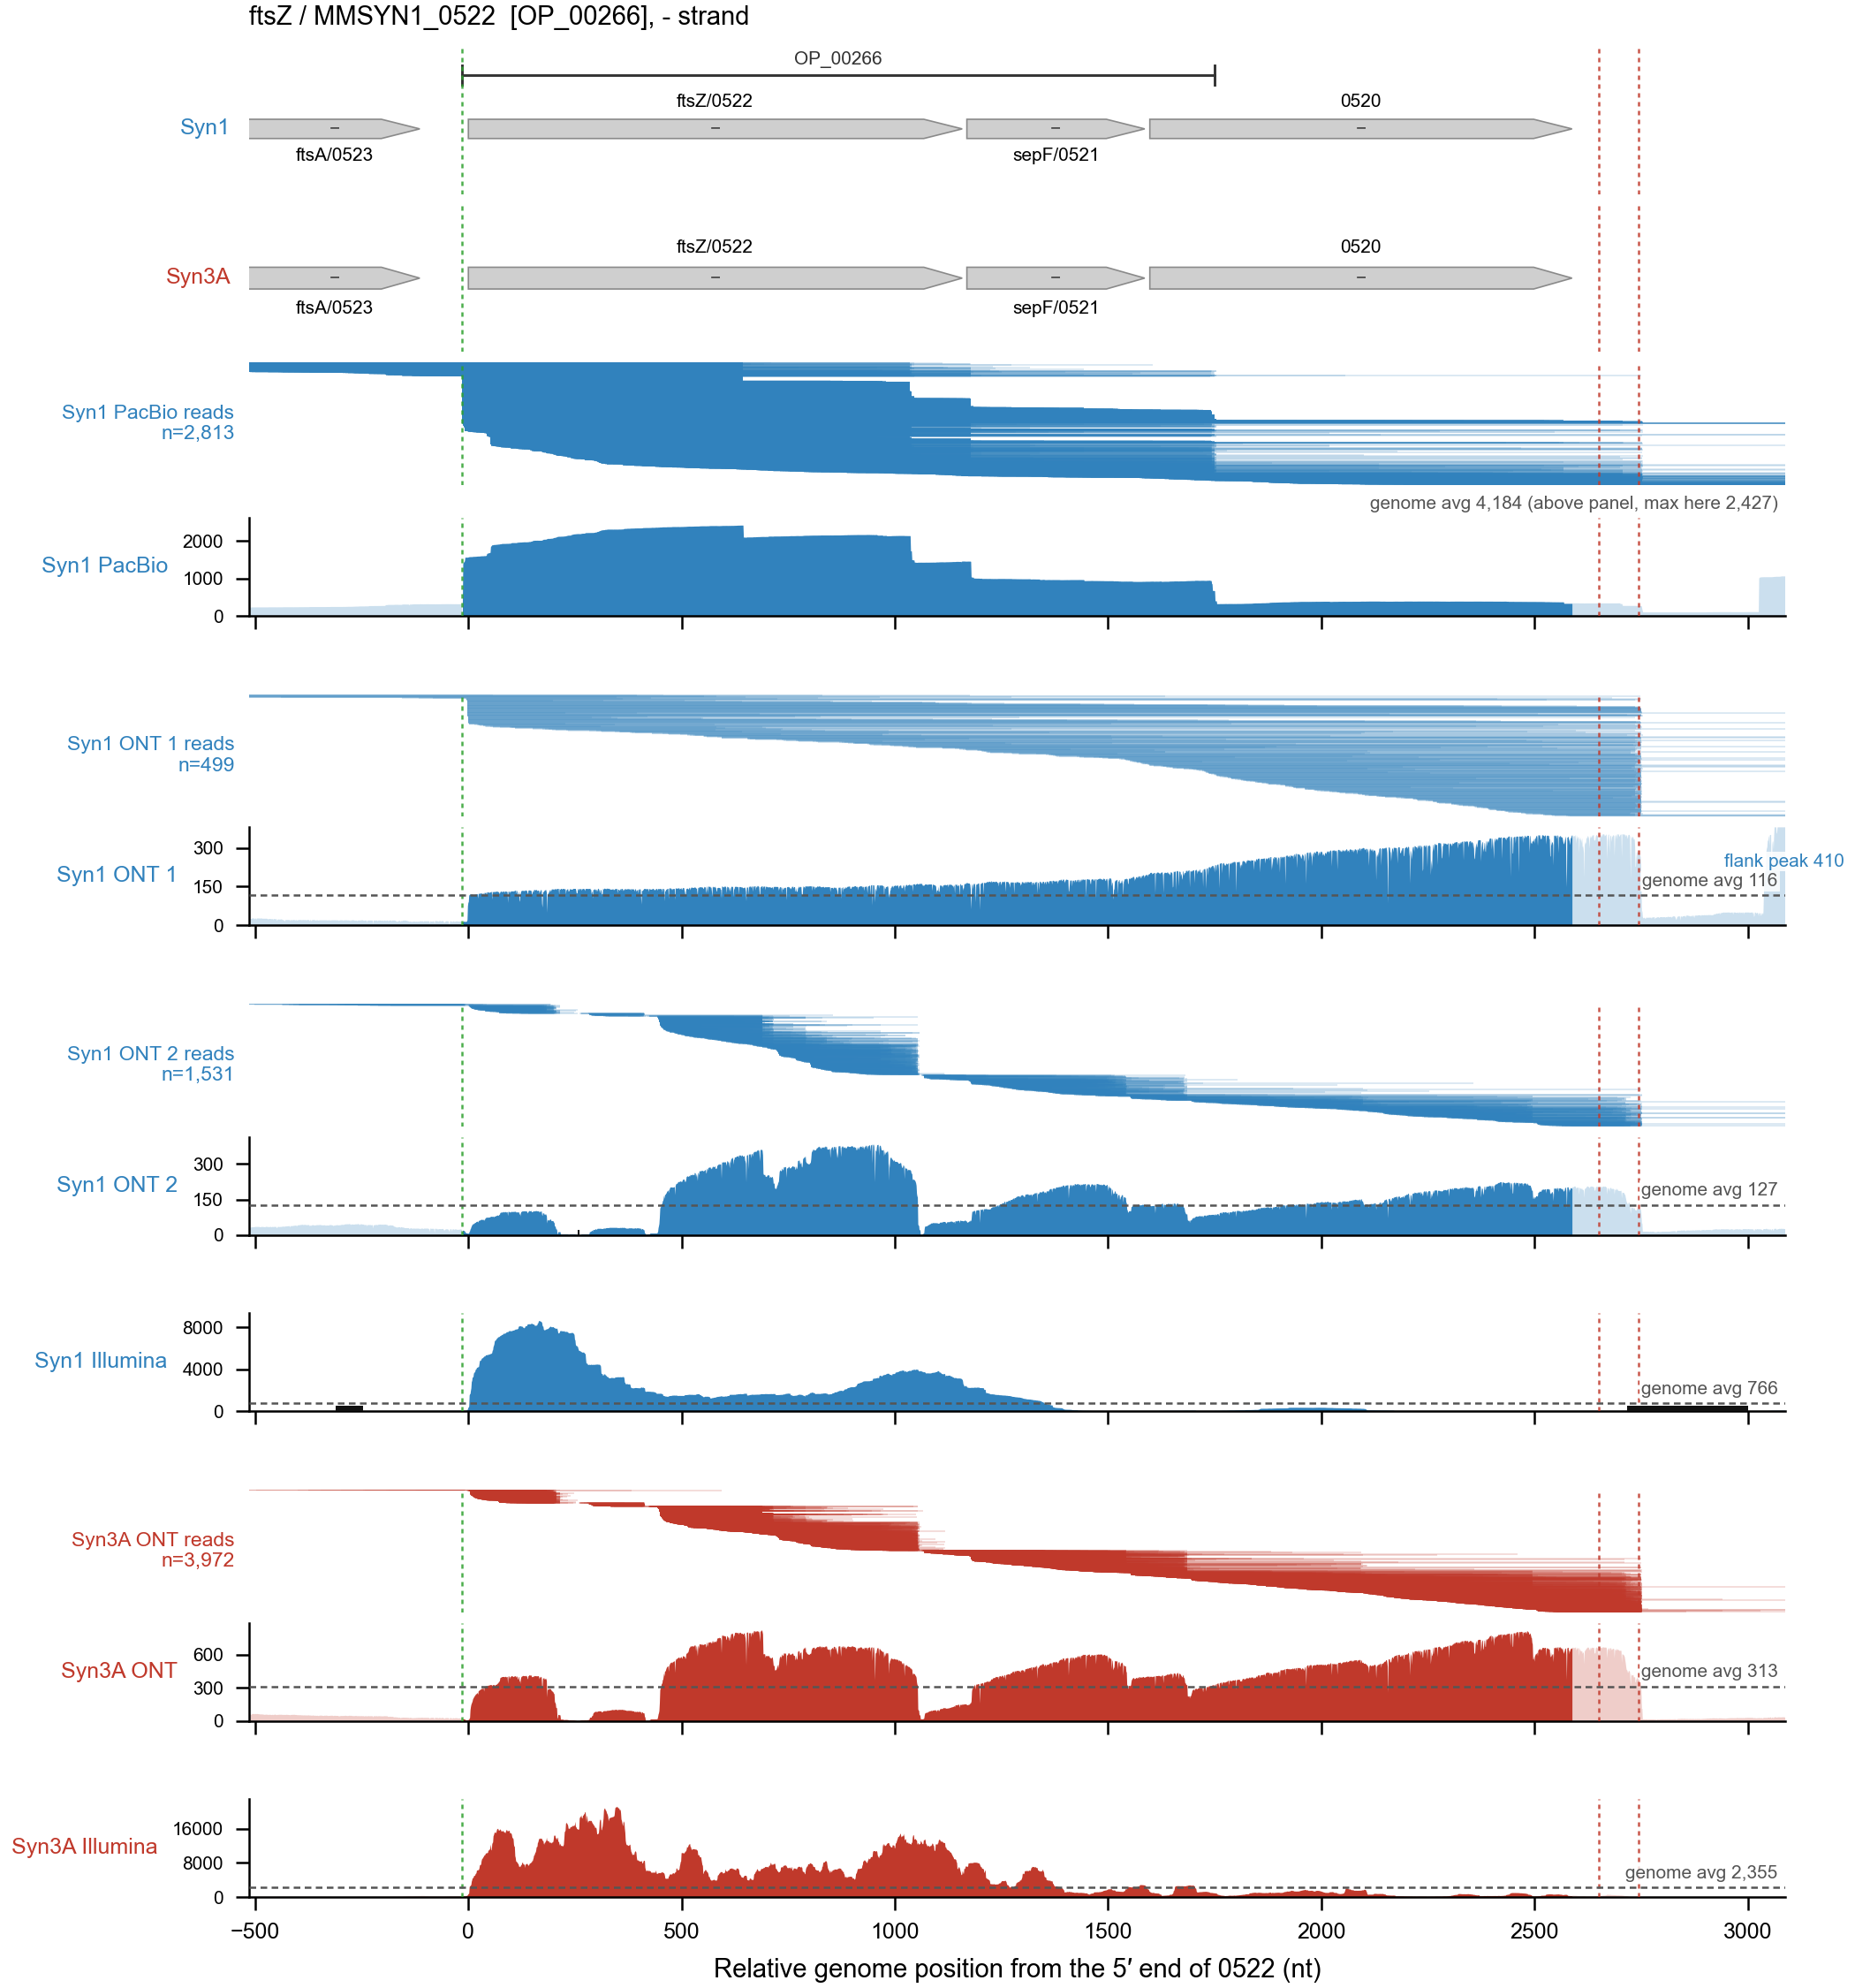

smpB / MMSYN1_0776  [OP_00387, OP_00389], + strand   ->  0776_smpB_transcription.png


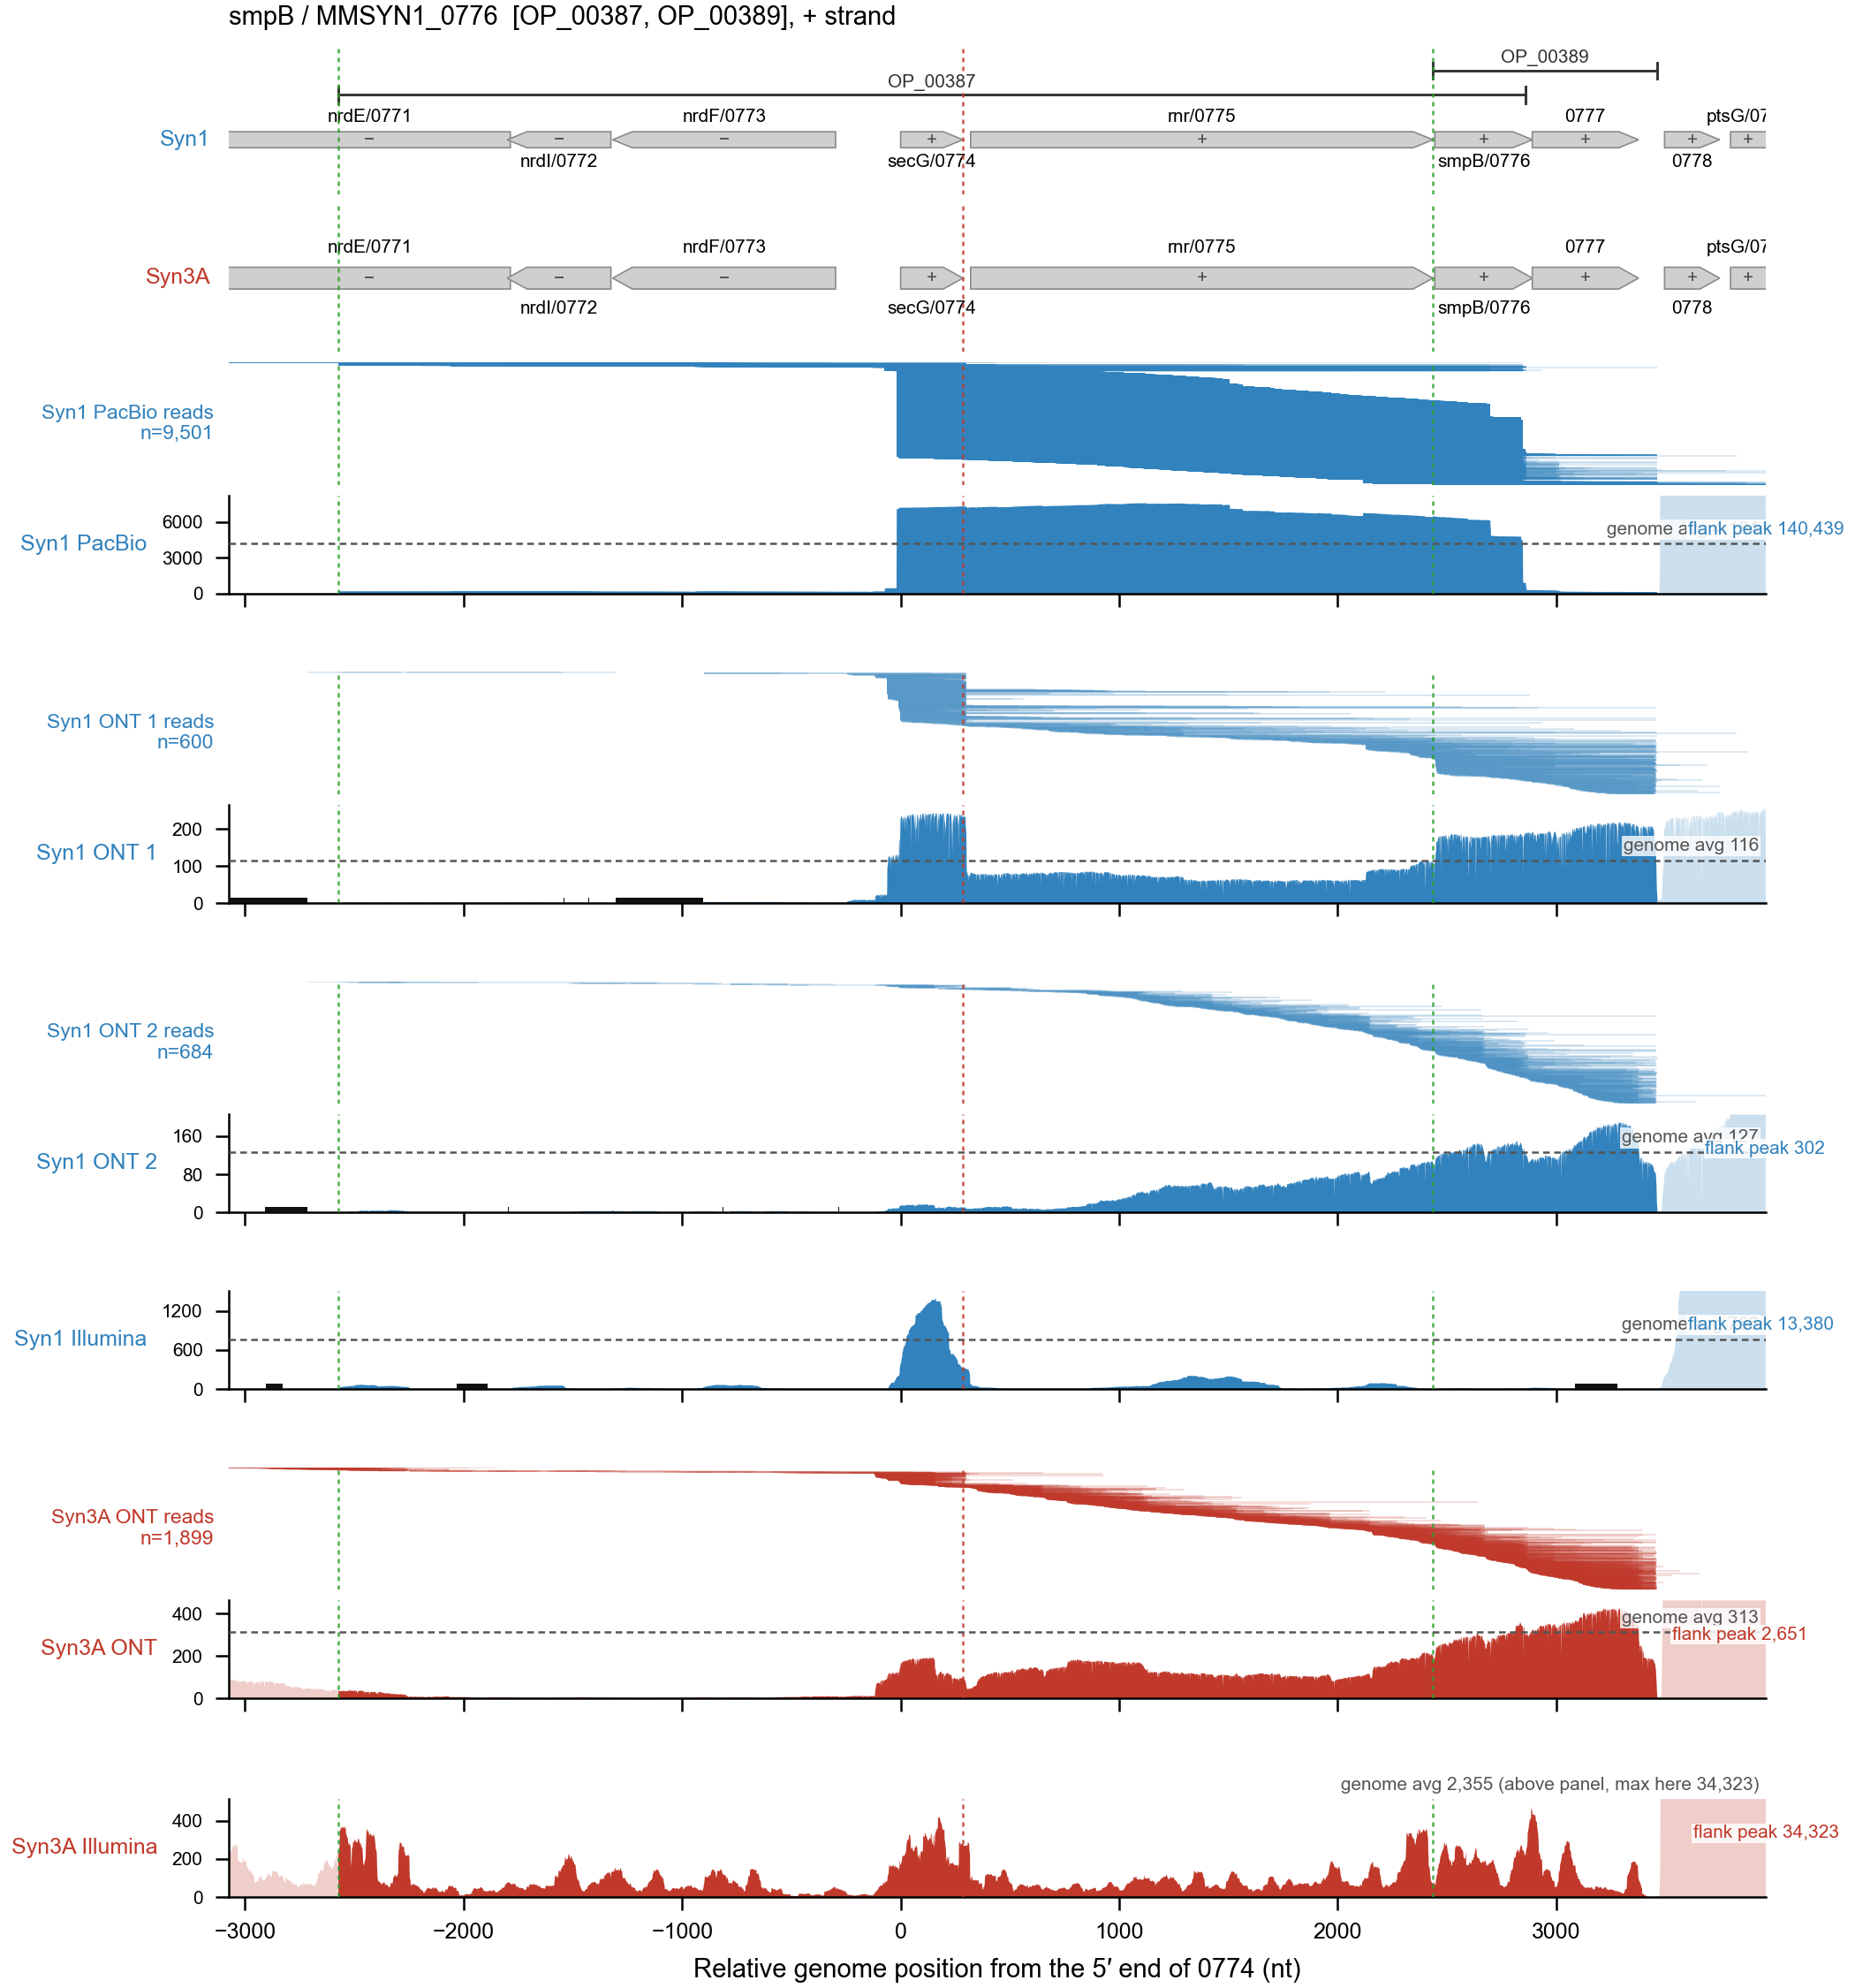

In [4]:
for g in ["ptsG", "ftsZ", "smpB"]:
    fig, txt, R = tv.plot_region(g)
    print(f"{R['title']}   ->  {R['files']['png'].split('/')[-1]}")
    tv.show(R)          # scaled to fit one screen; the exported PDF/PNG stay 7 in wide

## Inspect a region without drawing it

`build_region` is cheap (annotation tables only, no depth or BAM reads) — handy for checking the window before committing to a plot.

In [5]:
R = tv.build_region("ptsG")
print(R["title"])
print("anchor      ", R["anchor_num"], "| Syn1", f"{R['anchor1']:,}", "| Syn3A", f"{R['anchor3']:,}")
print("window rel  ", R["rel_lo"], "..", R["rel_hi"], "| Syn1", R["win"])
print("operon(s)   ", R["operons"], "| TSS", R["tss"])
print("Syn3A break ", R["brk"], "| deletion bands", R["bands"])
print("Syn1 genes  ", list(R["w1"].num))
print("Syn3A genes ", list(R["w3"].num))
R["w1"][["num", "label", "start0", "end0", "strand", "product"]]

ptsG / MMSYN1_0779  [OP_00390], + strand
anchor       0778 | Syn1 915,033 | Syn3A 460,164
window rel   -519 .. 5840 | Syn1 [914514, 920873]
operon(s)    ['OP_00390'] | TSS [915014]
Syn3A break  2619 | deletion bands [(2619, 5840)]
Syn1 genes   ['0777', '0778', '0779', '0780', '0781', '0782', '0783']
Syn3A genes  ['0777', '0778', '0779', '0787']


,num,label,start0,end0,strand,product
776,0777,,914428,914914,+,Uncharacterized protein
777,0778,,915033,915285,+,Uncharacterized protein
778,0779,ptsG,915335,917573,+,PTS sugar transporter
779,0780,tnpA_5,917650,918193,+,IS1296 transposase protein A
780,0781,tnpB_5,918330,919062,+,IS1296 transposase protein B
781,0782,,919156,920284,+,PSEUDOGENE - beta-lactamase
782,0783,,920379,921345,+,glucokinase
